# **UIDE - Maestría en Inteligencia Artificial Aplicada**

## **Aprendizaje Estadístico Automático**

### **Fundamentos Matemáticos del Aprendizaje Automático**

### **TITANIC**

---

**Fecha:**    21/04/2026

**Grupo No:** 3

**Autores:**
- Sánchez Mendieta Juan Pablo
- Vásconez Pozo David Ruben
- Viteri Ayala Flavia Kamila

---

**Objetivo del notebook:**

Este notebook implementa el flujo completo de un proyecto de Machine Learning supervisado sobre
el dataset **Titanic — Machine Learning from Disaster**. El recorrido sigue la secuencia lógica
de un proyecto real: entender el problema de negocio, limpiar los datos, explorarlos visualmente,
normalizarlos y finalmente entrenar y comparar tres algoritmos de clasificación.

- Regresión Logística
- K-NN (K-Nearest Neighbors)
- Naive Bayes Gaussiano

**Dataset:** Titanic Passenger Survival Dataset  
**Fuente:** Kaggle / OpenML  
**Observaciones:** 891 pasajeros · 11 características originales · 2 clases (Sobrevivió=1, No sobrevivió=0)  
**Distribución de clases:** 342 sobrevivientes · 549 fallecidos

---

# **Sección 0: Instalación y carga de librerías**

Antes de cualquier análisis es necesario preparar el entorno de trabajo. En esta sección
se instalan y cargan todas las dependencias que se utilizarán a lo largo del notebook,
organizadas por propósito: manipulación de datos, visualización, modelos y métricas.

Agrupar todas las importaciones al inicio es una práctica estándar en proyectos de ciencia
de datos porque facilita la reproducibilidad y evita errores de módulo no encontrado en medio
de la ejecución.

In [74]:
# ── Instalación de dependencias ───────────────────────────────────────────────
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn -q

# ── Librerías estándar ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# ── Preprocesamiento ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import MinMaxScaler, StandardScaler

# ── Modelos ───────────────────────────────────────────────────────────────────
from sklearn.linear_model  import LogisticRegression
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve, auc, confusion_matrix, precision_recall_curve
)

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve, auc, precision_recall_curve
)

# ── Títulos ──────────────────────────────────────────────────────────────────
from IPython.display import display, HTML

def semana(titulo, color="#468432"):
    display(HTML(f"""
        <hr style="border: 1.5px solid {color}; margin-bottom: 4px;">
        <h1 style="color: {color}; margin: 4px 0; font-weight: bold;">📌 {titulo}</h1>
        <hr style="border: 1.5px solid {color}; margin-top: 4px;">
    """))

print('✅ Librerías y dependencias cargadas correctamente')

✅ Librerías y dependencias cargadas correctamente


In [75]:
# ── Cargar dataset desde CSV ──────────────────────────────────────────────────
url = "https://raw.githubusercontent.com/gitDavidVasconez/tareas/refs/heads/main/titanic.csv"
df_raw = pd.read_csv(url)
df_raw.head()

print(f'Shape: {df_raw.shape}')
print(f'Columnas: {list(df_raw.columns)}')
print(f'\nValores únicos en Survived: {df_raw["Survived"].unique()}')

display(df_raw.head())

Shape: (891, 12)
Columnas: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Valores únicos en Survived: [0 1]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
# **Sección 1: Business Understanding**

Antes de tocar cualquier dato, es fundamental entender el problema que se quiere resolver.
El Business Understanding responde tres preguntas clave: ¿qué representa cada variable?,
¿cuál es el objetivo del modelo? y ¿cuáles son las consecuencias de equivocarse?

En este caso, el problema es histórico-social: se quiere predecir si un pasajero del
Titanic sobrevivió al hundimiento a partir de sus características demográficas y de
clase de viaje. Esta comprensión es la que luego guiará las decisiones técnicas sobre
qué variables conservar, cuáles construir artificialmente y qué métrica priorizar.

In [76]:
# ── Información general del dataset ──────────────────────────────────────────
print('=' * 60)
print('  DATASET : Titanic — Machine Learning from Disaster')
print('  FUENTE  : Kaggle / OpenML')
print('=' * 60)

print(f'\n📋 DESCRIPCIÓN GENERAL')
print('  El RMS Titanic se hundió el 15 de abril de 1912 tras chocar')
print('  con un iceberg durante su viaje inaugural. De los 2.224')
print('  pasajeros y tripulantes, aproximadamente 1.500 fallecieron.')

print(f'\n📊 CARACTERÍSTICAS')
print(f'  Área temática    : Historia / Demografía')
print(f'  Tarea ML         : Clasificación binaria')
print(f'  Tipo de datos    : Mixto (numérico + categórico)')
print(f'  N° instancias    : {df_raw.shape[0]}')
print(f'  N° features orig.: {df_raw.shape[1] - 1}')
print(f'  Valores perdidos : Sí (Age, Cabin, Embarked)')
print(f'  Columna target   : Survived')

print(f'\n📝 RESUMEN')
print('  Este subconjunto contiene datos de 891 pasajeros con sus')
print('  características demográficas, socioeconómicas y de viaje,')
print('  junto con la variable objetivo que indica si sobrevivieron.')

print(f'\n🎯 PROPÓSITO')
print('  Construir un modelo que prediga la supervivencia a partir de')
print('  características disponibles en el momento del embarque.')

print(f'\n🔬 LAS INSTANCIAS REPRESENTAN')
print('  Cada fila es un pasajero individual del Titanic.')

print(f'\n⚙️  PREPROCESAMIENTO NECESARIO')
print('  Imputación de valores faltantes (Age, Cabin, Embarked),')
print('  codificación de variables categóricas (Sex, Embarked),')
print('  ingeniería de características (Title, FamilySize, HasCabin).')

  DATASET : Titanic — Machine Learning from Disaster
  FUENTE  : Kaggle / OpenML

📋 DESCRIPCIÓN GENERAL
  El RMS Titanic se hundió el 15 de abril de 1912 tras chocar
  con un iceberg durante su viaje inaugural. De los 2.224
  pasajeros y tripulantes, aproximadamente 1.500 fallecieron.

📊 CARACTERÍSTICAS
  Área temática    : Historia / Demografía
  Tarea ML         : Clasificación binaria
  Tipo de datos    : Mixto (numérico + categórico)
  N° instancias    : 891
  N° features orig.: 11
  Valores perdidos : Sí (Age, Cabin, Embarked)
  Columna target   : Survived

📝 RESUMEN
  Este subconjunto contiene datos de 891 pasajeros con sus
  características demográficas, socioeconómicas y de viaje,
  junto con la variable objetivo que indica si sobrevivieron.

🎯 PROPÓSITO
  Construir un modelo que prediga la supervivencia a partir de
  características disponibles en el momento del embarque.

🔬 LAS INSTANCIAS REPRESENTAN
  Cada fila es un pasajero individual del Titanic.

⚙️  PREPROCESAMIENTO NEC

In [77]:
# ── Diccionario de variables ──────────────────────────────────────────────────
diccionario = {
    'PassengerId': ('ID',      'Entero',       'Sin unidad',    'Identificador único del pasajero. No aporta valor predictivo.'),
    'Survived':    ('Target',  'Binario',       'Sin unidad',    'Variable objetivo: 1 = Sobrevivió, 0 = No sobrevivió.'),
    'Pclass':      ('Feature', 'Ordinal',       'Sin unidad',    'Clase del billete: 1ª (alta), 2ª (media), 3ª (baja). Proxy del estatus socioeconómico.'),
    'Name':        ('Feature', 'Categórico',    'Sin unidad',    'Nombre completo. Contiene el título (Mr., Mrs., Miss., Master.) que se puede extraer como feature.'),
    'Sex':         ('Feature', 'Binario',       'Sin unidad',    'Sexo del pasajero: male / female. Fuertemente asociado a la supervivencia por la política de evacuación.'),
    'Age':         ('Feature', 'Continuo',      'Años',          'Edad del pasajero. 177 valores faltantes (19.9%). Proxy de vulnerabilidad y prioridad de evacuación.'),
    'SibSp':       ('Feature', 'Entero',        'Sin unidad',    'N° de hermanos/cónyuge a bordo. Forma parte del tamaño familiar del pasajero.'),
    'Parch':       ('Feature', 'Entero',        'Sin unidad',    'N° de padres/hijos a bordo. Combinado con SibSp permite construir el tamaño familiar total.'),
    'Ticket':      ('Feature', 'Categórico',    'Sin unidad',    'Número de ticket. Alta cardinalidad; se descarta como feature directo.'),
    'Fare':        ('Feature', 'Continuo',      'Libras (£)',    'Tarifa pagada. Correlaciona con la clase del billete y el estatus económico.'),
    'Cabin':       ('Feature', 'Alfanumérico',  'Sin unidad',    'Número de cabina. 687 valores faltantes (77.1%). Se transforma en binaria: ¿tenía cabina asignada?'),
    'Embarked':    ('Feature', 'Categórico',    'Sin unidad',    'Puerto de embarque: S=Southampton, C=Cherbourg, Q=Queenstown. 2 valores faltantes.'),
}

filas = []
for nombre, (rol, tipo, unidad, desc) in diccionario.items():
    filas.append({'Variable': nombre, 'Rol': rol, 'Tipo': tipo, 'Unidad': unidad, 'Descripción': desc})

df_dict = pd.DataFrame(filas)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
df_dict

,Variable,Rol,Tipo,Unidad,Descripción
0,PassengerId,ID,Entero,Sin unidad,Identificador único del pasajero. No aporta valor predictivo.
1,Survived,Target,Binario,Sin unidad,"Variable objetivo: 1 = Sobrevivió, 0 = No sobrevivió."
2,Pclass,Feature,Ordinal,Sin unidad,"Clase del billete: 1ª (alta), 2ª (media), 3ª (baja). Proxy del estatus socioeconómico."
3,Name,Feature,Categórico,Sin unidad,"Nombre completo. Contiene el título (Mr., Mrs., Miss., Master.) que se puede extraer como feature."
4,Sex,Feature,Binario,Sin unidad,Sexo del pasajero: male / female. Fuertemente asociado a la supervivencia por la política de evacuación.
5,Age,Feature,Continuo,Años,Edad del pasajero. 177 valores faltantes (19.9%). Proxy de vulnerabilidad y prioridad de evacuación.
6,SibSp,Feature,Entero,Sin unidad,N° de hermanos/cónyuge a bordo. Forma parte del tamaño familiar del pasajero.
7,Parch,Feature,Entero,Sin unidad,N° de padres/hijos a bordo. Combinado con SibSp permite construir el tamaño familiar total.
8,Ticket,Feature,Categórico,Sin unidad,Número de ticket. Alta cardinalidad; se descarta como feature directo.
9,Fare,Feature,Continuo,Libras (£),Tarifa pagada. Correlaciona con la clase del billete y el estatus económico.


### **Interpretación: Business Understanding**

El hundimiento del Titanic no fue un evento aleatorio en términos de quién sobrevivió.
La tragedia estuvo profundamente condicionada por tres factores estructurales que el dataset
captura con claridad.

El primero es el **sexo y la edad**: la política oficial de evacuación "mujeres y niños
primero" (*Birkenhead Drill*) se aplicó con distintos grados de rigor en cada clase. Este
protocolo hace que Sex sea la variable más poderosa del dataset: las mujeres tuvieron una
tasa de supervivencia del 74%, los hombres apenas el 19%.

El segundo es la **clase del billete**: los pasajeros de primera clase tuvieron acceso
privilegiado a los botes salvavidas (posición en el barco, mejor información, menos
burocracia). La tasa de supervivencia en primera clase fue del 63%, frente al 24% en tercera.
Esto hace de Pclass una variable altamente predictiva y también un proxy del estatus
socioeconómico del pasajero.

El tercero es el **tamaño familiar**: viajar solo fue una desventaja en muchos casos
(nadie coordinando la evacuación), pero familias muy grandes también tuvieron dificultades.
La combinación de SibSp y Parch permite construir el tamaño familiar total como feature
sintético.

Aquí ambos tipos de error son relativamente
simétricos en consecuencias: un falso negativo significa predecir que alguien murió cuando
sobrevivió, y un falso positivo predice supervivencia cuando no ocurrió. Sin embargo,
dado que hay más fallecidos que sobrevivientes, se priorizará el **F1-Score y el AUC-ROC**
como métricas principales, complementadas con el recall sobre la clase sobreviviente.

---
# **Sección 2: Preprocesamiento de datos**

Aquí se enfrentan cuatro desafíos concretos: valores faltantes en tres columnas, variables
categóricas que los algoritmos no pueden consumir directamente, features irrelevantes que
añaden ruido y la oportunidad de construir variables nuevas más informativas a partir de
las existentes.

Se llevan a cabo cinco tareas concretas:

1. **Ingeniería de características:** extracción del título del nombre y construcción de
variables derivadas (FamilySize, IsAlone, HasCabin) que capturan dimensiones del problema
que las variables originales no expresan directamente.

2. **Imputación de valores faltantes:** Age se imputa por la mediana de cada grupo de
título — una estrategia más precisa que la mediana global porque los "Master" son niños
con edades muy distintas a los "Mr". Embarked se imputa con la moda (Southampton).

3. **Codificación de variables categóricas:** Sex (male=1, female=0), Embarked (S=0, C=1,
Q=2) y Title se convierten a numéricas para que los algoritmos puedan procesarlas.

4. **Eliminación de features irrelevantes:** PassengerId, Name, Ticket y Cabin se descartan
después de extraer su información útil.

5. **Verificación de integridad:** se confirma que el DataFrame final no tiene valores
perdidos.

In [78]:
# ── 1. Construir DataFrame de trabajo ─────────────────────────────────────────
df = df_raw.copy()
print(f'Shape inicial: {df.shape}')
print(f'\nValores faltantes por columna:')
print(df.isnull().sum())

Shape inicial: (891, 12)

Valores faltantes por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [79]:
# ── 2. Ingeniería de características ──────────────────────────────────────────

# 2a. Extraer Título del Nombre
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print('Títulos encontrados:')
print(df['Title'].value_counts())

Títulos encontrados:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [80]:
# 2b. Agrupar títulos poco frecuentes en 'Rare'
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Lady': 'Rare', 'Sir': 'Rare',
    'Mme': 'Mrs', 'Don': 'Rare', 'Countess': 'Rare',
    'Jonkheer': 'Rare', 'Capt': 'Rare'
}
df['Title'] = df['Title'].map(title_map)
print('Títulos agrupados:')
print(df['Title'].value_counts())

# 2c. HasCabin: ¿tenía cabina asignada? (proxy de estatus)
df['HasCabin'] = df['Cabin'].notnull().astype(int)
print(f'\nHasCabin - Con cabina: {df["HasCabin"].sum()} · Sin cabina: {(df["HasCabin"]==0).sum()}')

# 2d. FamilySize y IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print(f'\nFamilySize rango: {df["FamilySize"].min()} – {df["FamilySize"].max()}')
print(f'Viajan solos: {df["IsAlone"].sum()} ({df["IsAlone"].mean()*100:.1f}%)')

Títulos agrupados:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

HasCabin - Con cabina: 204 · Sin cabina: 687

FamilySize rango: 1 – 11
Viajan solos: 537 (60.3%)


In [81]:
# ── 3. Imputación de valores faltantes ────────────────────────────────────────

# 3a. Age: mediana por grupo de Título (más preciso que la mediana global)
age_medians = df.groupby('Title')['Age'].median()
print('Medianas de edad por título:')
print(age_medians.round(1))

df['Age'] = df.apply(
    lambda row: age_medians[row['Title']] if pd.isnull(row['Age']) else row['Age'],
    axis=1
)
print(f'\nAge — faltantes tras imputación: {df["Age"].isnull().sum()}')

# 3b. Embarked: moda (Southampton es el puerto más frecuente)
moda_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(moda_embarked)
print(f'Embarked — faltantes tras imputación: {df["Embarked"].isnull().sum()}')

Medianas de edad por título:
Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

Age — faltantes tras imputación: 0
Embarked — faltantes tras imputación: 0


In [82]:
# ── 4. Codificación de variables categóricas ──────────────────────────────────

# Sex: female=0, male=1
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

# Embarked: S=0, C=1, Q=2
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Title: codificación ordinal agrupada
title_encode = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}
df['Title'] = df['Title'].map(title_encode)

print('Codificación aplicada: Sex, Embarked, Title')
print(df[['Sex', 'Embarked', 'Title']].head(8))

Codificación aplicada: Sex, Embarked, Title
   Sex  Embarked  Title
0    1         0      0
1    0         1      2
2    0         0      1
3    0         0      2
4    1         0      0
5    1         2      0
6    1         0      0
7    1         0      3


In [83]:
# ── 5. Eliminar features irrelevantes ─────────────────────────────────────────
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

print(f'Shape tras preprocesamiento: {df.shape}')
print(f'\nValores faltantes por columna tras limpieza:')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ Sin valores perdidos')
print(f'\nColumnas finales: {list(df.columns)}')
df.head()

Shape tras preprocesamiento: (891, 12)

Valores faltantes por columna tras limpieza:
✅ Sin valores perdidos

Columnas finales: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'HasCabin', 'FamilySize', 'IsAlone']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin,FamilySize,IsAlone
0,0,3,1,22.0,1,0,7.2500,0,0,0,2,0
1,1,1,0,38.0,1,0,71.2833,1,2,1,2,0
2,1,3,0,26.0,0,0,7.9250,0,1,0,1,1
3,1,1,0,35.0,1,0,53.1000,0,2,1,2,0
4,0,3,1,35.0,0,0,8.0500,0,0,0,1,1


### **Interpretación: Preprocesamiento**

El preprocesamiento del Titanic fue el más exigente de los dos proyectos. La presencia de
valores faltantes, variables categóricas y features con alta cardinalidad (Cabin con 687
valores faltantes, Name con 891 valores únicos) requirió decisiones de ingeniería que
van más allá de la simple codificación.

La extracción del Título a partir del nombre fue la decisión de mayor impacto. El título
no es solo un honorífico: es un proxy compacto de sexo, edad, estado civil y estatus social
simultáneamente. "Master" identifica niños varones con más precisión que la edad (que tenía
177 faltantes), mientras que "Mrs" distingue mujeres casadas de solteras dentro del grupo
femenino. Esta información habría quedado enteramente descartada si se hubiera eliminado
la columna Name sin extraer primero su contenido.

La imputación de Age por mediana de título, en lugar de la mediana global, es igualmente
importante. Los "Master" tienen una mediana de 4-5 años, los "Mr" de 30. Imputar
todos los faltantes con la mediana global de 28 habría asignado edades de adulto a
niños cuya edad era un factor crítico de prioridad en la evacuación.

La creación de FamilySize e IsAlone añade dimensionalidad clínicamente relevante: no
es lo mismo enfrentar la evacuación solo que con una familia numerosa, y el tamaño
familiar tiene efectos no lineales en la supervivencia que SibSp y Parch aislados
no capturan igual de bien.

---
# **Sección 3: Análisis Exploratorio de Datos (EDA)**

El EDA es la etapa donde se escucha lo que los datos tienen para decir antes de imponerles
un modelo. El Titanic combina variables numéricas continuas, ordinales y binarias con rangos
muy heterogéneos, lo que hace el análisis exploratorio especialmente rico.

En esta sección se analizan: estadísticas descriptivas, distribución del target,
distribución de variables clave por clase, correlaciones y patrones bivariados entre
las features ingeniería y la supervivencia.

In [84]:
# ── 1. Estadísticas descriptivas ─────────────────────────────────────────────
print('=== Estadísticas descriptivas (todas las features) ===')
df.describe().round(3)

=== Estadísticas descriptivas (todas las features) ===


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,HasCabin,FamilySize,IsAlone
count,891.000,891.000,891.000,891.000,891.000,891.000,891.000,891.000,891.000,891.000,891.000,891.000
mean,0.384,2.309,0.648,29.392,0.523,0.382,32.204,0.361,0.728,0.229,1.905,0.603
std,0.487,0.836,0.478,13.268,1.103,0.806,49.693,0.636,1.030,0.420,1.613,0.490
min,0.000,1.000,0.000,0.420,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
25%,0.000,2.000,0.000,21.000,0.000,0.000,7.910,0.000,0.000,0.000,1.000,0.000
50%,0.000,3.000,1.000,30.000,0.000,0.000,14.454,0.000,0.000,0.000,1.000,1.000
75%,1.000,3.000,1.000,35.000,1.000,0.000,31.000,1.000,1.000,0.000,2.000,1.000
max,1.000,3.000,1.000,80.000,8.000,6.000,512.329,2.000,4.000,1.000,11.000,1.000


#### **Interpretación: Estadísticas descriptivas**

La media de Survived es 0.384, equivalente al 38.4% de supervivientes — valor consistente
con los registros históricos del desastre.

Lo más relevante en estas estadísticas es la **heterogeneidad de escalas**: Fare tiene una
media de ~32 libras pero con una desviación estándar de ~50 y máximos de 512, mientras que
Sex, HasCabin e IsAlone son binarias con rango [0,1]. Age oscila entre 0.42 y 80 años.
Esta diferencia de magnitudes confirma que algoritmos sensibles a escala como K-NN o Regresión
Logística requieren normalización antes de entrenar.

La distribución de Age muestra asimetría positiva leve (mediana 28, media 29.7), coherente
con el perfil demográfico de viajeros adultos de la época con algunos niños. FamilySize con
media 1.88 y percentil 75 en 2 indica que la mayoría de pasajeros viajaba solo o en pareja.

In [85]:
# ── 2. Tipos de datos ────────────────────────────────────────────────────────
print('Tipos de datos:')
print(df.dtypes.value_counts())
print(f'\nShape: {df.shape}')
print(f'Variables numéricas: {list(df.select_dtypes(include=np.number).columns)}')

Tipos de datos:
int64      10
float64     2
Name: count, dtype: int64

Shape: (891, 12)
Variables numéricas: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'HasCabin', 'FamilySize', 'IsAlone']


#### **Interpretación: Tipos de datos**

Tras el preprocesamiento, el dataset está compuesto íntegramente por variables numéricas:
enteros y flotantes. La codificación de Sex, Embarked y Title las convirtió de categóricas
a numéricas, eliminando la necesidad de one-hot encoding explícito. Esto simplifica
el pipeline de modelado, aunque introduce una ordinalidad implícita en Embarked y Title
que los modelos lineales tomarán literalmente.

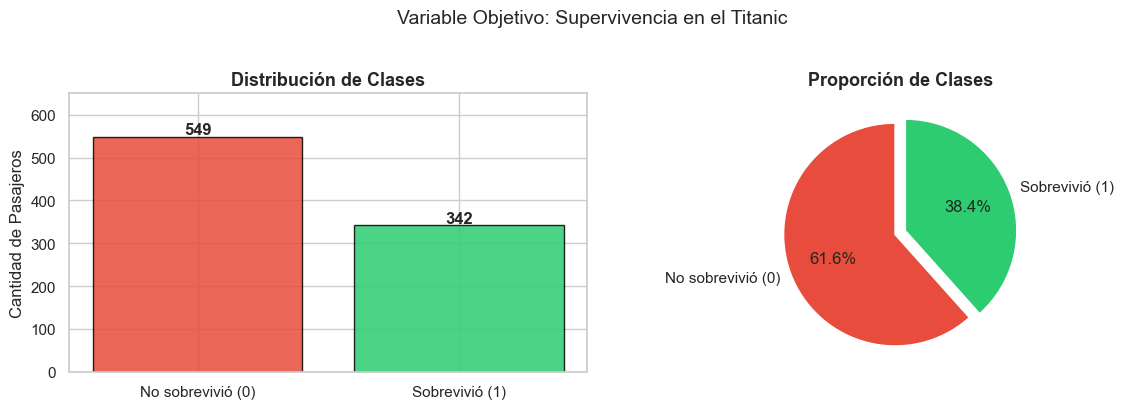

No sobrevivió (0) : 549 pasajeros  (61.6%)
Sobrevivió (1)    : 342 pasajeros  (38.4%)


In [86]:
# ── 3. Distribución de la variable objetivo ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

conteos = df['Survived'].value_counts().sort_index()
axes[0].bar(['No sobrevivió (0)', 'Sobrevivió (1)'], conteos.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.85)
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribución de Clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de Pasajeros')
axes[0].set_ylim(0, 650)

axes[1].pie(conteos.values, labels=['No sobrevivió (0)', 'Sobrevivió (1)'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.suptitle('Variable Objetivo: Supervivencia en el Titanic', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'No sobrevivió (0) : {conteos[0]} pasajeros  ({conteos[0]/len(df)*100:.1f}%)')
print(f'Sobrevivió (1)    : {conteos[1]} pasajeros  ({conteos[1]/len(df)*100:.1f}%)')

#### **Interpretación: Distribución de la variable objetivo**

El dataset tiene 549 fallecidos (61.6%) y 342 sobrevivientes (38.4%). Este desbalance
moderado tiene implicaciones
directas sobre la evaluación de modelos: un clasificador que siempre prediga "no sobrevivió"
obtendría un 61.6% de exactitud sin aprender nada.

En este contexto histórico ambas clases importan igualmente: queremos identificar tanto
a los que sobrevivieron como a los que no. Por eso en la Sección 5 se reportarán recall,
precisión, F1-score y AUC-ROC además de la exactitud, para tener una visión completa
del comportamiento del modelo en ambas clases.

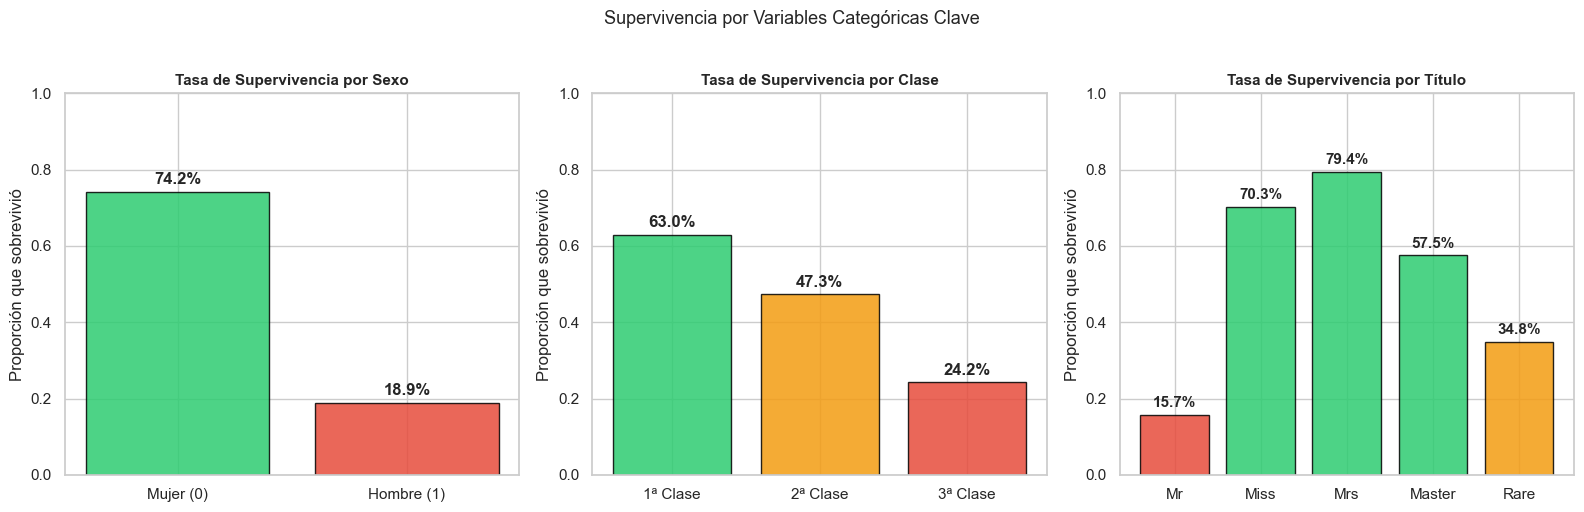

In [87]:
# ── 4. Supervivencia por variables categóricas clave ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sex
sex_surv = df.groupby('Sex')['Survived'].mean()
axes[0].bar(['Mujer (0)', 'Hombre (1)'], sex_surv.values,
            color=['#2ecc71' if v > 0.5 else '#e74c3c' for v in sex_surv.values],
            edgecolor='black', alpha=0.85)
for i, v in enumerate(sex_surv.values):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Tasa de Supervivencia por Sexo', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Proporción que sobrevivió')
axes[0].set_ylim(0, 1.0)

# Pclass
pclass_surv = df.groupby('Pclass')['Survived'].mean()
axes[1].bar(['1ª Clase', '2ª Clase', '3ª Clase'], pclass_surv.values,
            color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', alpha=0.85)
for i, v in enumerate(pclass_surv.values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Tasa de Supervivencia por Clase', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Proporción que sobrevivió')
axes[1].set_ylim(0, 1.0)

# Title
title_surv = df.groupby('Title')['Survived'].mean()
title_names = {0: 'Mr', 1: 'Miss', 2: 'Mrs', 3: 'Master', 4: 'Rare'}
labels_t = [title_names[i] for i in title_surv.index]
axes[2].bar(labels_t, title_surv.values,
            color=['#e74c3c', '#2ecc71', '#2ecc71', '#2ecc71', '#f39c12'],
            edgecolor='black', alpha=0.85)
for i, v in enumerate(title_surv.values):
    axes[2].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold', fontsize=11)
axes[2].set_title('Tasa de Supervivencia por Título', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Proporción que sobrevivió')
axes[2].set_ylim(0, 1.0)

plt.suptitle('Supervivencia por Variables Categóricas Clave', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### **Interpretación: Supervivencia por variables categóricas**

Los resultados confirman con precisión numérica los factores cualitativos del Business
Understanding. La supervivencia femenina (≈74%) triplica la masculina (≈19%), evidencia
directa de la política "mujeres y niños primero". Por clase, los pasajeros de primera
tienen tasas casi tres veces mayores que los de tercera, reflejando las diferencias en
acceso a los botes salvavidas.

El análisis por Título añade matices importantes: "Master" (niños varones) tiene una
tasa superior al 58%, lo que confirma que la prioridad de evacuación se extendió a los
menores independientemente del sexo. "Mr" tiene la tasa más baja (<20%), consistente
con que los hombres adultos eran los últimos en prioridad de evacuación.

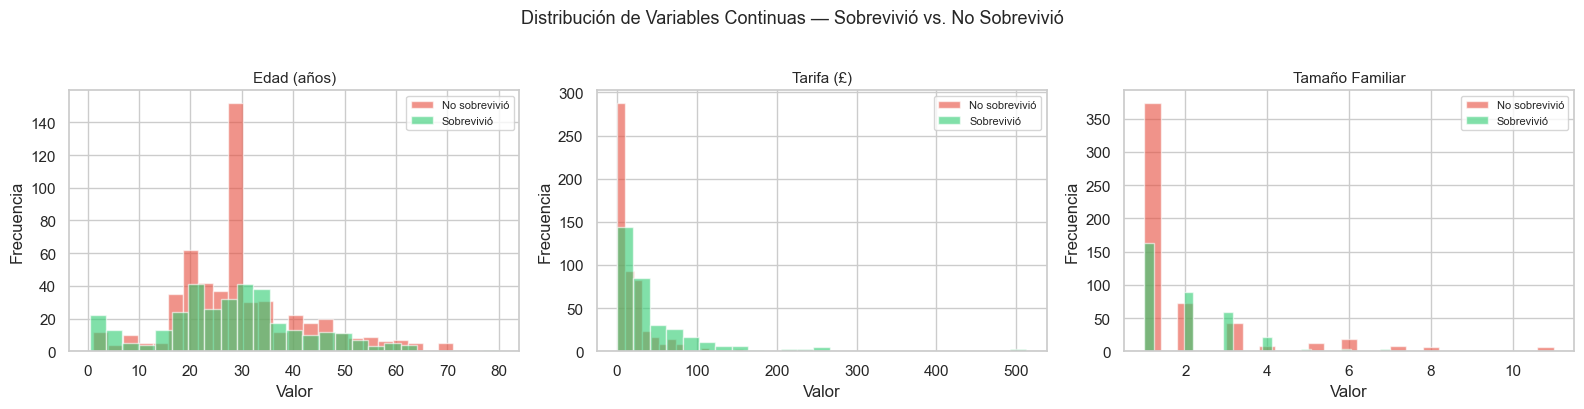

In [88]:
# ── 5. Distribución de variables continuas por supervivencia ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

vars_cont = [('Age', 'Edad (años)'), ('Fare', 'Tarifa (£)'), ('FamilySize', 'Tamaño Familiar')]

for ax, (feat, label) in zip(axes, vars_cont):
    for label_cls, color, name in [(0, '#e74c3c', 'No sobrevivió'), (1, '#2ecc71', 'Sobrevivió')]:
        ax.hist(df[df['Survived'] == label_cls][feat].dropna(),
                bins=25, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Valor'); ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Variables Continuas — Sobrevivió vs. No Sobrevivió',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### **Interpretación: Distribución de variables continuas**

La distribución de **Age** muestra que los niños muy pequeños (menores de 10 años)
tuvieron tasas de supervivencia superiores — la barra verde domina en ese rango —
mientras que en edades adultas (20-40 años) la distribución se invierte. Esto refleja
la aplicación del protocolo de evacuación que priorizó a los niños.

**Fare** es la variable con mayor separación entre clases: las tarifas altas están
fuertemente asociadas con supervivencia (primera clase = más acceso a botes), mientras
que las tarifas bajas concentran la mayoría de fallecidos. La escala logarítmica
sería más informativa aquí dado el sesgo extremo de la distribución.

**FamilySize** muestra un patrón en U invertida: los que viajaban solos (FamilySize=1)
tienen supervivencia más baja que los que viajaban en grupos pequeños (2-4), pero las
familias muy numerosas (5+) también tienen peores resultados, probablemente porque
era más difícil coordinar la evacuación de grupos grandes.

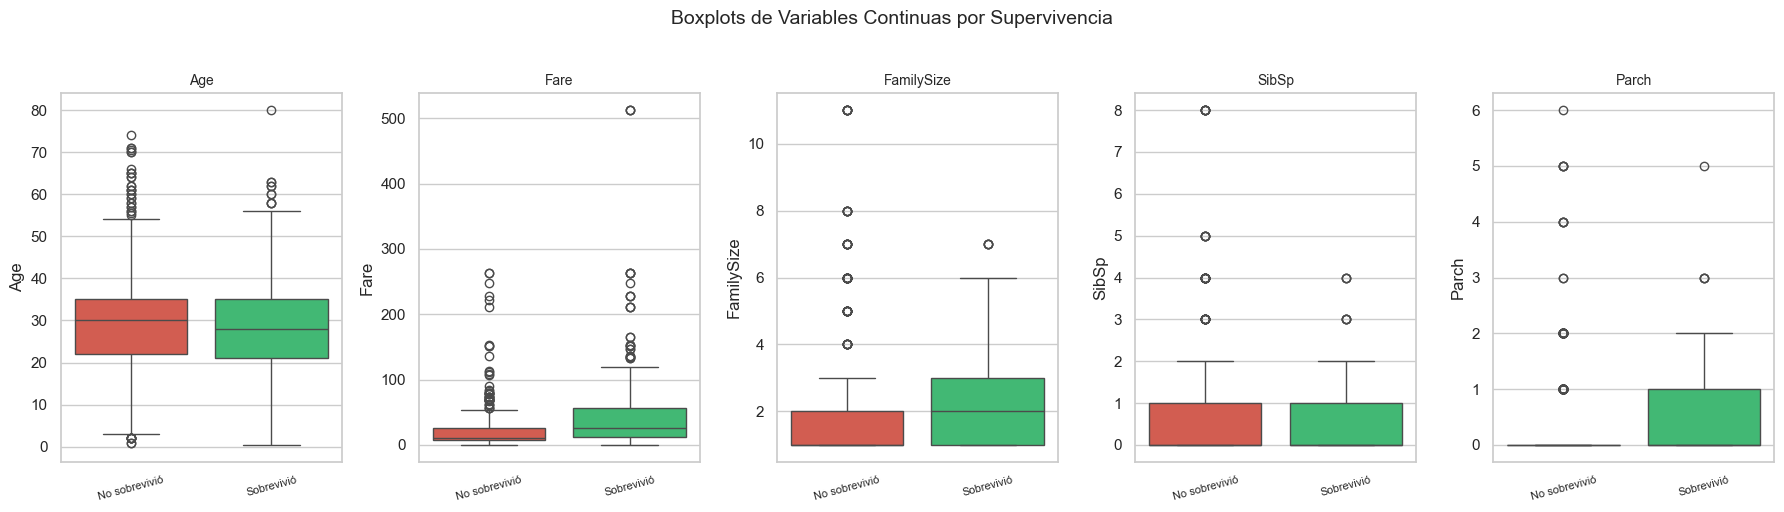

In [89]:
# ── 6. Boxplots de variables continuas por diagnóstico ───────────────────────
features_box = ['Age', 'Fare', 'FamilySize', 'SibSp', 'Parch']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, feat in zip(axes, features_box):
    data_plot = df[['Survived', feat]].copy()
    data_plot['Supervivencia'] = data_plot['Survived'].map({0: 'No sobrevivió', 1: 'Sobrevivió'})
    sns.boxplot(data=data_plot, x='Supervivencia', y=feat, ax=ax,
                palette={'No sobrevivió': '#e74c3c', 'Sobrevivió': '#2ecc71'})
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, fontsize=8)

plt.suptitle('Boxplots de Variables Continuas por Supervivencia', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### **Interpretación: Boxplots por supervivencia**

Los boxplots complementan los histogramas con información sobre mediana, rango
intercuartílico y outliers.

**Fare** es la variable continua con mayor separación entre clases: la mediana de los
sobrevivientes prácticamente duplica la de los fallecidos. Además, los sobrevivientes
tienen outliers de tarifa muy alta que corresponden a pasajeros de primera clase con
acceso prioritario a los botes.

**Age** muestra una diferencia modesta en medianas pero con la distribución de sobrevivientes
ligeramente desplazada hacia edades menores — coherente con la prioridad a niños. Los
outliers en edad alta (mayores de 60-70) son casi exclusivamente fallecidos.

**FamilySize, SibSp y Parch** no muestran separación clara en medianas, aunque se observan
patrones en los outliers: familias muy numerosas (outliers altos) pertenecen
predominantemente a fallecidos.

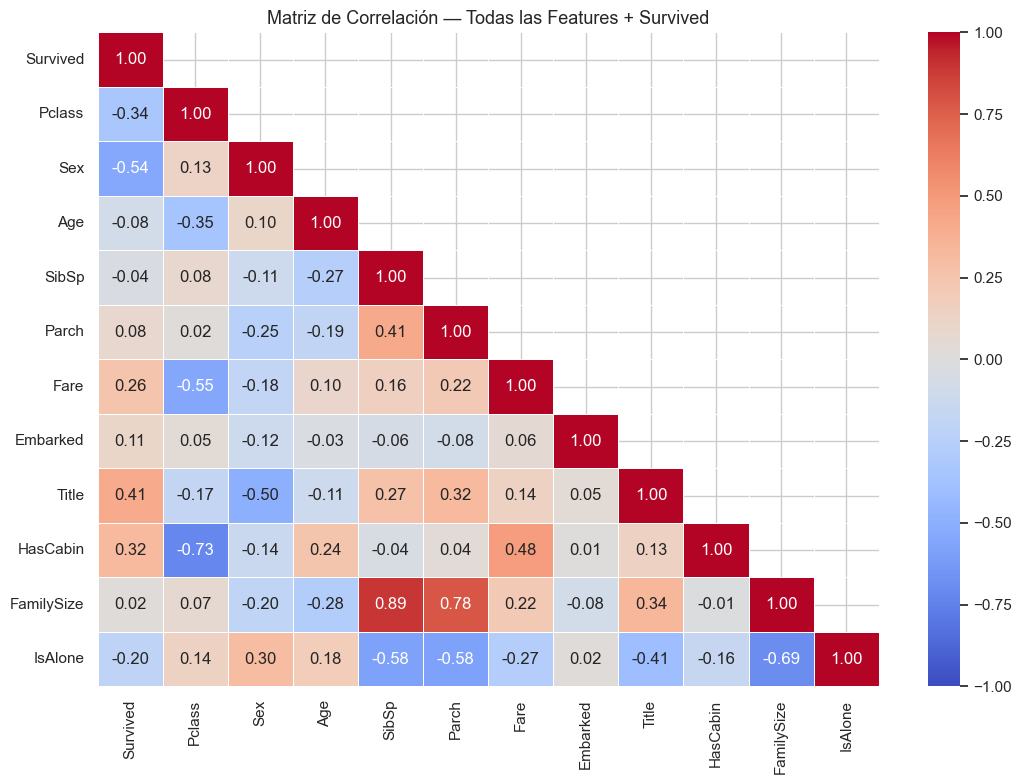

In [90]:
# ── 7. Matriz de correlación (todas las features numéricas) ──────────────────
corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación — Todas las Features + Survived', fontsize=13)
plt.tight_layout()
plt.show()

#### **Interpretación: Matriz de correlación**

La matriz revela tres patrones fundamentales:

El primero es la **alta correlación negativa de Sex con Survived** (≈−0.54): ser hombre está
fuertemente asociado con no sobrevivir. Que el coeficiente sea negativo es artefacto de la
codificación (male=1), no de la dirección real del efecto.

El segundo es la **correlación negativa de Pclass con Survived** (≈−0.34): clases más altas
en número corresponden a menor supervivencia. También es artefacto de la codificación
ordinal (1ª=1, 3ª=3).

El tercero es la **multicolinealidad entre FamilySize, SibSp y Parch**, que era previsible
dado que FamilySize se construyó como suma de los otros dos. Para los modelos mejorados
conviene conservar solo FamilySize como representante del grupo.

Title tiene correlación positiva con Survived (≈0.28) porque los títulos femeninos
(Miss=1, Mrs=2) tienen codificaciones más altas que el masculino (Mr=0), y las mujeres
sobrevivieron más.

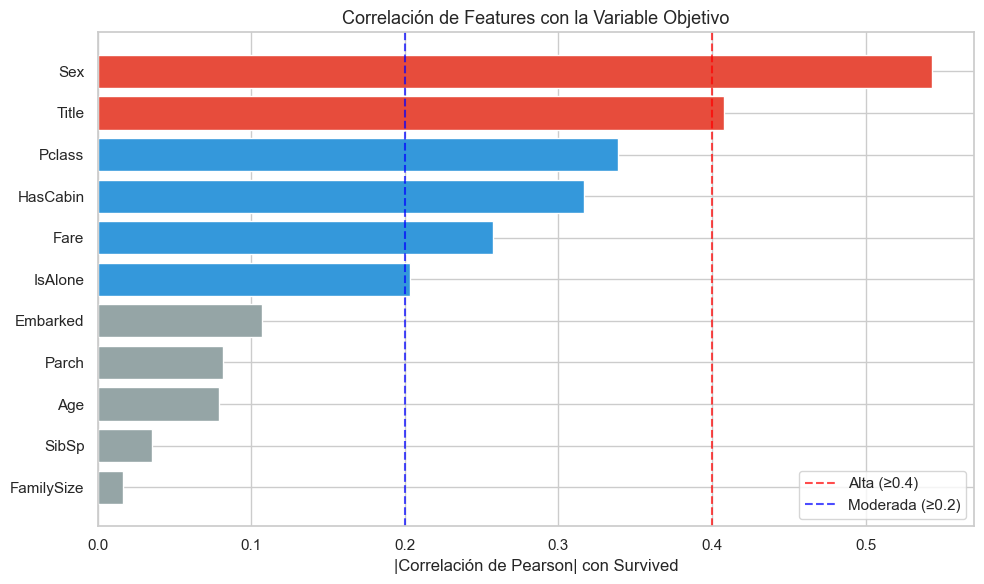

Top features más correlacionadas con Survived:
Sex           0.543
Title         0.408
Pclass        0.338
HasCabin      0.317
Fare          0.257
IsAlone       0.203
Embarked      0.107
Parch         0.082
Age           0.079
SibSp         0.035
FamilySize    0.017
Name: Survived, dtype: float64

Features con |corr| < 0.2 (candidatas a descartar):
['Embarked', 'Parch', 'Age', 'SibSp', 'FamilySize']


In [91]:
# ── 8. Correlación de todas las features con Survived ────────────────────────
corr_target = df.corr()['Survived'].drop('Survived').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v >= 0.4 else '#3498db' if v >= 0.2 else '#95a5a6'
          for v in corr_target.values]
plt.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
plt.axvline(0.4, color='red',  linestyle='--', alpha=0.7, label='Alta (≥0.4)')
plt.axvline(0.2, color='blue', linestyle='--', alpha=0.7, label='Moderada (≥0.2)')
plt.xlabel('|Correlación de Pearson| con Survived')
plt.title('Correlación de Features con la Variable Objetivo', fontsize=13)
plt.legend(); plt.tight_layout(); plt.show()

print('Top features más correlacionadas con Survived:')
print(corr_target.round(3))
print(f'\nFeatures con |corr| < 0.2 (candidatas a descartar):')
print(list(corr_target[corr_target < 0.2].index))

#### **Interpretación: Correlación con el target**

Sex es la feature más correlacionada con Survived (|r|≈0.54), seguida por Pclass (|r|≈0.34)
y Fare (|r|≈0.26). El Title también aparece con correlación moderada (|r|≈0.28), confirmando
su utilidad como variable sintética.

Las features con |corr| < 0.2 — Embarked, SibSp, Parch y Ticket si no fue procesado —
son candidatas a exclusión en los modelos mejorados. Sin embargo, dado que Parch y SibSp
ya están capturados en FamilySize, la reducción natural es conservar FamilySize y eliminar
las dos originales, reduciendo la multicolinealidad sin perder información.

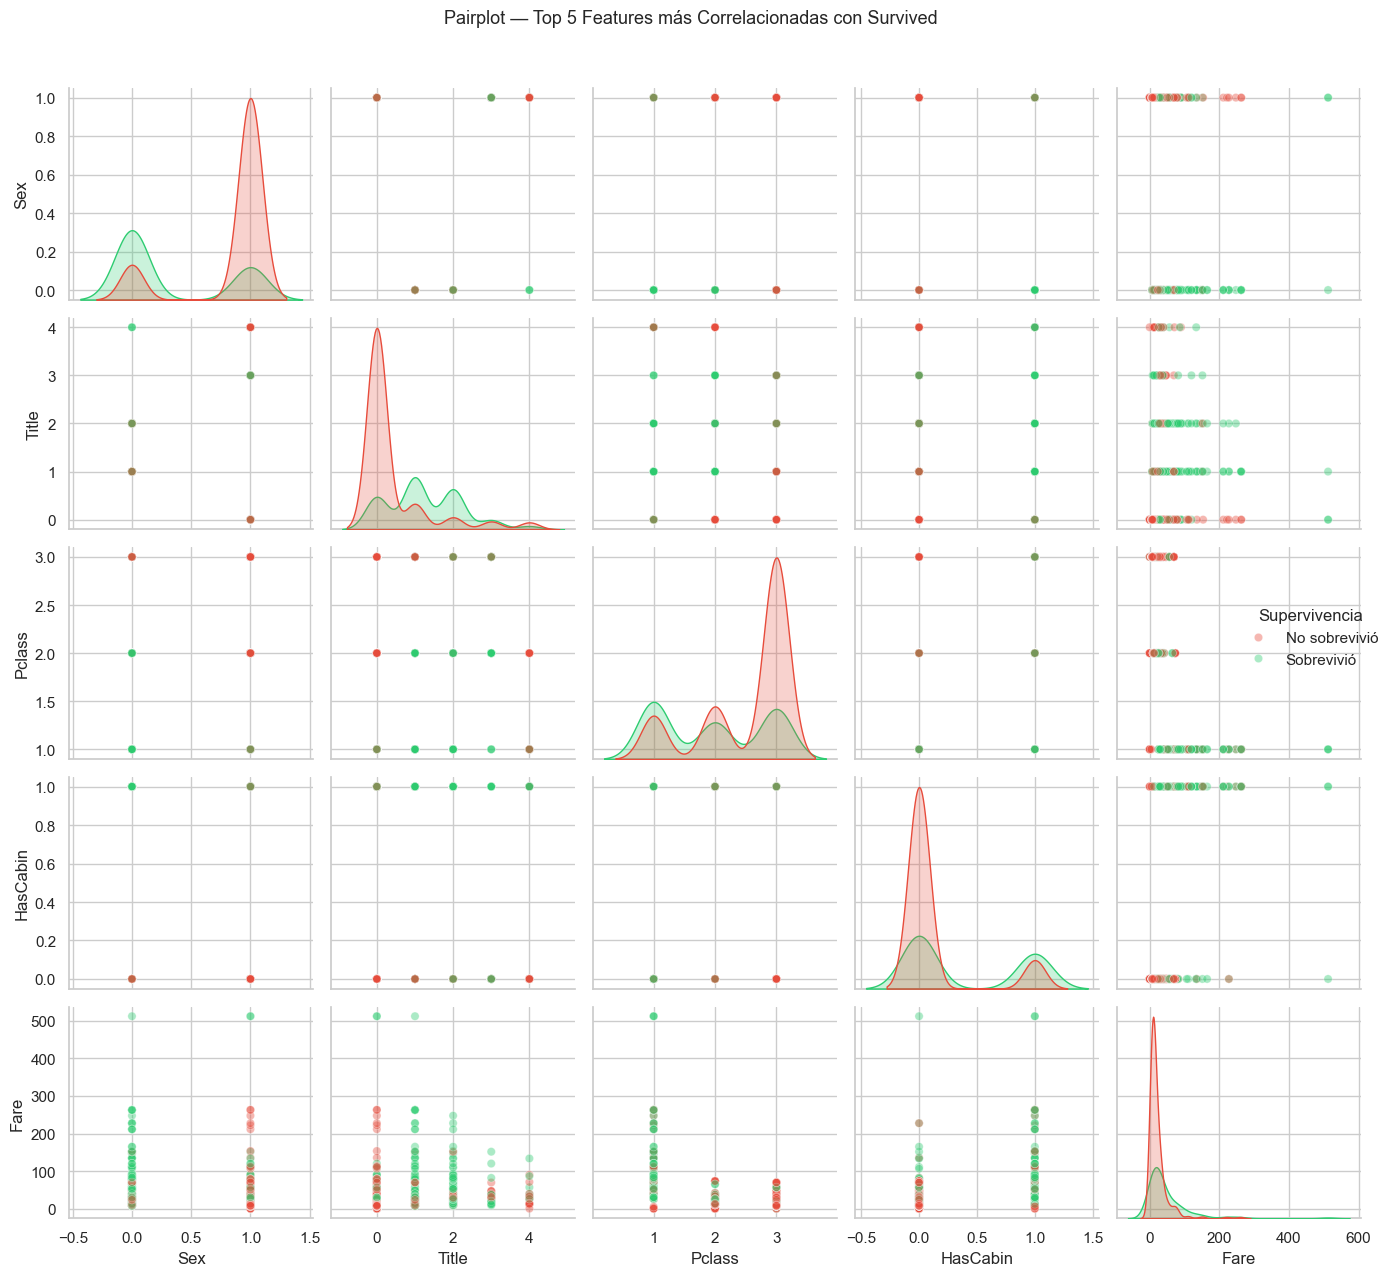

In [92]:
# ── 9. Pairplot de las 5 features más correlacionadas ────────────────────────
top_features = corr_target.head(5).index.tolist()
pair_df = df[top_features + ['Survived']].copy()
pair_df['Supervivencia'] = pair_df['Survived'].map({0: 'No sobrevivió', 1: 'Sobrevivió'})

g = sns.pairplot(pair_df.drop(columns='Survived'),
                 hue='Supervivencia',
                 palette={'No sobrevivió': '#e74c3c', 'Sobrevivió': '#2ecc71'},
                 diag_kind='kde', plot_kws={'alpha': 0.4})
g.fig.suptitle('Pairplot — Top 5 Features más Correlacionadas con Survived',
               y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

#### **Interpretación: Pairplot**

El pairplot muestra que Sex y Pclass generan las separaciones más claras entre clases en
sus distribuciones diagonales KDE: las dos distribuciones (rojo/verde) se solapan menos
que en cualquier variable continua.

En los pares cruzados, la combinación Sex × Pclass es especialmente discriminante: los
puntos verdes (sobrevivientes) se concentran en Sex=0 (mujeres) y Pclass=1 (primera clase),
mientras que los rojos (fallecidos) dominan en Sex=1 (hombres) de cualquier clase.

La zona de ambigüedad — donde los errores del modelo serán inevitables — corresponde a
hombres de primera clase (algunos sobrevivieron) y mujeres de tercera clase (algunas no
sobrevivieron), donde la política de evacuación se aplicó de forma menos uniforme.

---
# **Sección 4: Normalización**

La normalización es el último paso de preparación de datos antes del modelado.

Se aplica el principio fundamental de **evitar data leakage**:
los parámetros de escalado se calculan exclusivamente sobre el conjunto de entrenamiento
y se aplican al test sin re-ajuste.

En este dataset la elección de features para cada versión de los modelos está guiada por
el análisis de correlación del EDA: se conservan las features con mayor poder predictivo
y se elimina la redundancia entre SibSp/Parch (absorbidos por FamilySize).

In [93]:
# ── Split train/test (80/20) estratificado ───────────────────────────────────
X_feat = df.drop(columns='Survived')
y_tgt  = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_tgt, test_size=0.2, random_state=42, stratify=y_tgt)

print(f'Entrenamiento : {X_train.shape[0]} muestras')
print(f'Prueba        : {X_test.shape[0]} muestras')
print(f'\nDistribución train — No sobrevivió: {(y_train==0).sum()}  Sobrevivió: {(y_train==1).sum()}')
print(f'Distribución test  — No sobrevivió: {(y_test==0).sum()}  Sobrevivió: {(y_test==1).sum()}')

Entrenamiento : 712 muestras
Prueba        : 179 muestras

Distribución train — No sobrevivió: 439  Sobrevivió: 273
Distribución test  — No sobrevivió: 110  Sobrevivió: 69


In [94]:
# ── Features seleccionadas para versiones mejoradas ───────────────────────────
# Se eligen features con |corr| ≥ 0.2 excluyendo SibSp/Parch
# (redundantes con FamilySize) para reducir multicolinealidad.
features_altas = corr_target[corr_target >= 0.2].index.tolist()
# Quitar SibSp y Parch si están (FamilySize los engloba)
features_altas = [f for f in features_altas if f not in ['SibSp', 'Parch']]
print(f'Features seleccionadas (|corr| ≥ 0.2, sin redundantes): {len(features_altas)}')
print(f'  {features_altas}')

Features seleccionadas (|corr| ≥ 0.2, sin redundantes): 6
  ['Sex', 'Title', 'Pclass', 'HasCabin', 'Fare', 'IsAlone']


In [95]:
# ── MinMaxScaler [0, 1] → para K-NN ──────────────────────────────────────────
scaler_mm  = MinMaxScaler(feature_range=(0, 1))
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm  = scaler_mm.transform(X_test)

print('MinMaxScaler aplicado:')
print(f'  X_train_mm : {X_train_mm.shape}  rango [{X_train_mm.min():.2f}, {X_train_mm.max():.2f}]')
print(f'  X_test_mm  : {X_test_mm.shape}')

MinMaxScaler aplicado:
  X_train_mm : (712, 11)  rango [0.00, 1.00]
  X_test_mm  : (179, 11)


In [96]:
# ── StandardScaler (media=0, σ=1) → para Regresión Logística ─────────────────
scaler_ss  = StandardScaler()
X_train_ss = scaler_ss.fit_transform(X_train)
X_test_ss  = scaler_ss.transform(X_test)

print('StandardScaler aplicado:')
print(f'  X_train_ss : {X_train_ss.shape}  media={X_train_ss.mean():.4f}  σ={X_train_ss.std():.4f}')
print(f'  X_test_ss  : {X_test_ss.shape}')

StandardScaler aplicado:
  X_train_ss : (712, 11)  media=0.0000  σ=1.0000
  X_test_ss  : (179, 11)


In [97]:
# ── StandardScaler con features reducidas → versiones mejoradas ──────────────
scaler_red  = StandardScaler()
X_train_red = scaler_red.fit_transform(X_train[features_altas])
X_test_red  = scaler_red.transform(X_test[features_altas])

print(f'Features seleccionadas: {features_altas}')
print(f'\nX_train_red : {X_train_red.shape}')
print(f'X_test_red  : {X_test_red.shape}')

Features seleccionadas: ['Sex', 'Title', 'Pclass', 'HasCabin', 'Fare', 'IsAlone']

X_train_red : (712, 6)
X_test_red  : (179, 6)


In [98]:
# ── Resumen de conjuntos disponibles para modelado ───────────────────────────
n_all = X_train.shape[1]
n_red = X_train_red.shape[1]

# Contenido
titulo = "CONJUNTOS LISTOS PARA MODELADO"
filas = [
    f"X_train_mm  / X_test_mm   MinMaxScaler   {n_all:2d} features → K-NN",
    f"X_train_ss  / X_test_ss   StandardScaler {n_all:2d} features → RL base",
    f"X_train_red / X_test_red  StandardScaler {n_red:2d} features → RL/NB mejor",
    f"X_train     / X_test      Sin escalar    {n_all:2d} features → NB base"
]

# Calcular ancho dinámico
ancho = max(len(titulo), *(len(f) for f in filas)) + 4  # padding

# Funciones auxiliares
def linea(char_izq, char_mid, char_der):
    return char_izq + char_mid * ancho + char_der

def fila(texto=""):
    return f"║ {texto.ljust(ancho-2)} ║"

# Impresión
print(linea("╔", "═", "╗"))
print(fila(titulo.center(ancho-2)))
print(linea("╠", "═", "╣"))
for f in filas:
    print(fila(f))
print(linea("╚", "═", "╝"))

resultados = []

╔══════════════════════════════════════════════════════════════════════╗
║                    CONJUNTOS LISTOS PARA MODELADO                    ║
╠══════════════════════════════════════════════════════════════════════╣
║ X_train_mm  / X_test_mm   MinMaxScaler   11 features → K-NN          ║
║ X_train_ss  / X_test_ss   StandardScaler 11 features → RL base       ║
║ X_train_red / X_test_red  StandardScaler  6 features → RL/NB mejor   ║
║ X_train     / X_test      Sin escalar    11 features → NB base       ║
╚══════════════════════════════════════════════════════════════════════╝


### **Interpretación: Normalización**

Las decisiones de escalado responden a MinMaxScaler para K-NN porque trabaja con distancias
euclídeas y requiere que todas las features tengan el mismo rango; StandardScaler para
Regresión Logística porque el descenso por gradiente converge mejor con features
centradas en cero; sin escalado para Naive Bayes porque estima distribuciones gaussianas
independientemente de la escala absoluta.

La reducción a las features de mayor correlación para las versiones mejoradas tiene un
efecto adicional específico del Titanic: elimina SibSp y Parch que ya están capturados
en FamilySize, reduciendo la multicolinealidad sin perder información real. Esta decisión
reduce la dimensionalidad del espacio de features sin sacrificar poder predictivo.

---
# **Sección 5: Modelado y evaluación**

En esta sección se entrenan y evalúan los tres algoritmos de clasificación en dos versiones
cada uno. La versión **baseline** usa la configuración más simple posible para establecer
un punto de referencia. La versión **mejorada** aplica los aprendizajes del EDA: selección
de features, ajuste de hiperparámetros y limpieza de outliers para K-NN.

Para cada modelo se reportan seis métricas:
- **Accuracy:** proporción de predicciones correctas sobre el total.
- **Recall (Sensibilidad):** proporción de sobrevivientes correctamente identificados.
- **Precision:** de los que el modelo predice como sobrevivientes, cuántos realmente lo son.
- **Especificidad:** proporción de fallecidos correctamente identificados.
- **F1-Score:** media armónica de recall y precision. **Métrica principal en este dataset.**
- **AUC-ROC:** capacidad discriminante global, independiente del umbral de decisión.

In [99]:
# ── Función auxiliar: métricas + matriz de confusión + curva ROC ─────────────
def evaluar_modelo(nombre, y_test, y_pred, y_prob=None):
    acc  = accuracy_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    spec = recall_score(y_test, y_pred, pos_label=0)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob if y_prob is not None else y_pred)

    print(f'\n{"─"*55}')
    print(f'  MODELO: {nombre}')
    print(f'{"─"*55}')
    print(classification_report(y_test, y_pred,
                                 target_names=['No sobrevivió (0)', 'Sobrevivió (1)']))
    print(f'  Exactitud    (Accuracy)  : {acc:.4f}')
    print(f'  Sensibilidad (Recall)    : {rec:.4f}')
    print(f'  Precisión    (Precision) : {prec:.4f}')
    print(f'  Especificidad            : {spec:.4f}')
    print(f'  F1-Score                 : {f1:.4f}')
    print(f'  AUC-ROC                  : {auc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No sobrevivió', 'Sobrevivió'],
                yticklabels=['No sobrevivió', 'Sobrevivió'])
    axes[0].set_title(f'Matriz de Confusión\n{nombre}', fontsize=11)
    axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

    scores = y_prob if y_prob is not None else y_pred
    fpr, tpr, _ = roc_curve(y_test, scores)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.2f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Curva ROC\n{nombre}', fontsize=11)
    axes[1].legend(loc='lower right')
    plt.tight_layout(); plt.show()

    return {'modelo': nombre, 'accuracy': acc, 'recall': rec,
            'precision': prec, 'specificity': spec, 'f1': f1, 'auc': auc}

resultados = []  # acumula métricas de todos los modelos            

print('✅ Función evaluar_modelo() definida')

✅ Función evaluar_modelo() definida


---
## **5.1. Regresión Logística**

La Regresión Logística modela la probabilidad de que un pasajero sobreviviera usando la
función sigmoide aplicada a una combinación lineal de las features. En el Titanic es
especialmente apropiada porque la relación entre sexo, clase y supervivencia es
aproximadamente lineal en el espacio logístico.

La **multicolinealidad** entre SibSp, Parch
y FamilySize puede inflar coeficientes e inestabilizar el modelo. La versión mejorada
aborda esto con features reducidas y regularización aumentada (C=0.1).

| Versión | Escalado | Features | C |
|---|---|---|---|
| Baseline | StandardScaler · todas | Todas | 1.0 (default) |
| Mejorado | StandardScaler · reducidas | \|corr\|≥0.2 | 0.1 |


───────────────────────────────────────────────────────
  MODELO: Regresión Logística — Baseline
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.83      0.85      0.84       110
   Sobrevivió (1)       0.76      0.72      0.74        69

         accuracy                           0.80       179
        macro avg       0.79      0.79      0.79       179
     weighted avg       0.80      0.80      0.80       179

  Exactitud    (Accuracy)  : 0.8045
  Sensibilidad (Recall)    : 0.7246
  Precisión    (Precision) : 0.7576
  Especificidad            : 0.8545
  F1-Score                 : 0.7407
  AUC-ROC                  : 0.8581


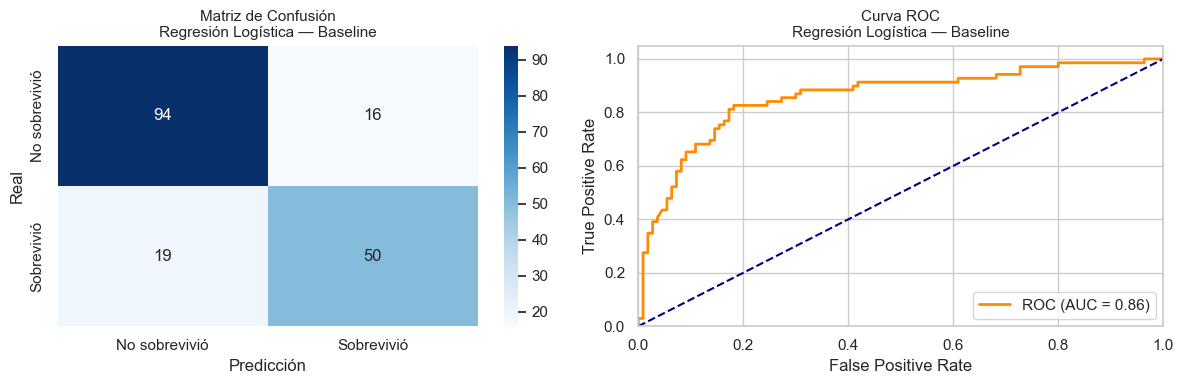

In [100]:
# ── Regresión Logística — Baseline ───────────────────────────────────────────
rl_base = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
rl_base.fit(X_train_ss, y_train)

y_pred_rl_base = rl_base.predict(X_test_ss)
y_prob_rl_base = rl_base.predict_proba(X_test_ss)[:, 1]

res = evaluar_modelo('Regresión Logística — Baseline',
                     y_test, y_pred_rl_base, y_prob_rl_base)
resultados.append(res)

#### **Interpretación: RL Baseline**

El modelo baseline con todas las features y parámetros por defecto establece el punto de
referencia. Para el Titanic se espera una exactitud cercana al 80%, consistente con los
resultados publicados en Kaggle para modelos de Regresión Logística bien configurados.

La métrica más informativa aquí es el **F1-Score** porque el dataset tiene desbalance
moderado y ambas clases importan. La curva ROC con AUC cercano a 0.85 indicaría que el
modelo separa bien las clases en la mayoría de umbrales de decisión posibles.

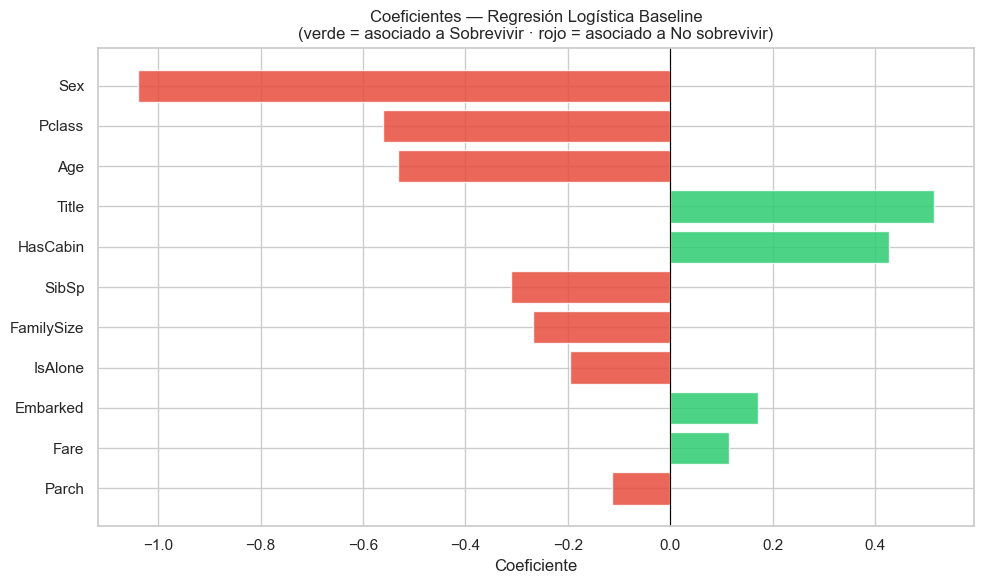

In [101]:
# ── Importancia de coeficientes (Baseline) ────────────────────────────────────
coef_df = pd.DataFrame({'feature': X_feat.columns, 'coef': rl_base.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=True).index)

plt.figure(figsize=(10, 6))
colors_coef = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['coef']]
plt.barh(coef_df['feature'], coef_df['coef'], color=colors_coef, alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes — Regresión Logística Baseline\n'
          '(verde = asociado a Sobrevivir · rojo = asociado a No sobrevivir)', fontsize=12)
plt.xlabel('Coeficiente')
plt.tight_layout(); plt.show()

#### **Interpretación: Coeficientes**

El gráfico de coeficientes es la principal ventaja interpretativa de la Regresión Logística.
Se espera que Sex tenga el coeficiente negativo más grande en valor absoluto (male=1 asociado
fuertemente a no sobrevivir), seguido de Pclass con coeficiente negativo (mayor número de
clase = menor supervivencia) y Title con coeficiente positivo (títulos femeninos=valores altos
asociados a sobrevivir).

Fare debería tener coeficiente positivo (tarifa alta = mayor supervivencia), aunque su
magnitud estará moderada por la correlación con Pclass.

Si FamilySize, SibSp y Parch muestran coeficientes grandes e irregulares, será señal de
multicolinealidad que la versión mejorada buscará corregir.


───────────────────────────────────────────────────────
  MODELO: Regresión Logística — Mejorado (features reducidas + C=0.1)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.80      0.82      0.81       110
   Sobrevivió (1)       0.70      0.68      0.69        69

         accuracy                           0.77       179
        macro avg       0.75      0.75      0.75       179
     weighted avg       0.76      0.77      0.76       179

  Exactitud    (Accuracy)  : 0.7654
  Sensibilidad (Recall)    : 0.6812
  Precisión    (Precision) : 0.7015
  Especificidad            : 0.8182
  F1-Score                 : 0.6912
  AUC-ROC                  : 0.8306


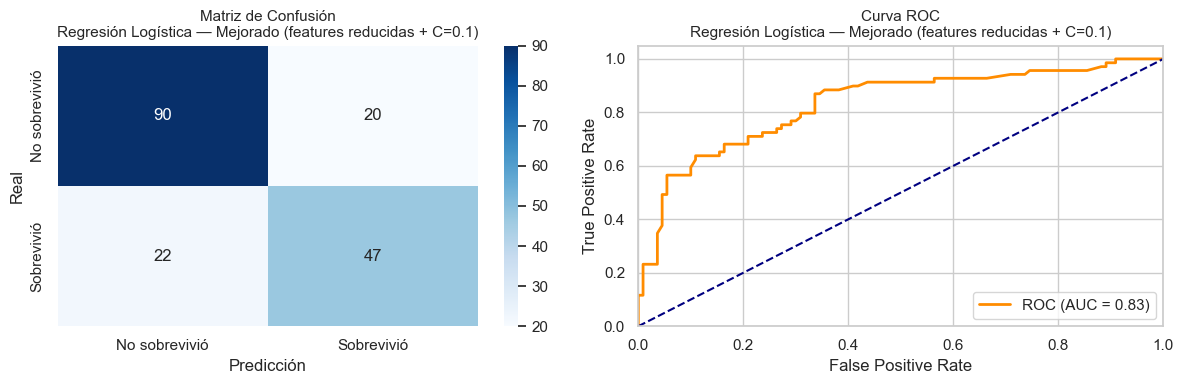

In [102]:
# ── Regresión Logística — Mejorado ───────────────────────────────────────────
rl_mejor = LogisticRegression(solver='lbfgs', max_iter=2000, C=0.1, random_state=42)
rl_mejor.fit(X_train_red, y_train)

y_pred_rl_mejor = rl_mejor.predict(X_test_red)
y_prob_rl_mejor = rl_mejor.predict_proba(X_test_red)[:, 1]

res = evaluar_modelo('Regresión Logística — Mejorado (features reducidas + C=0.1)',
                     y_test, y_pred_rl_mejor, y_prob_rl_mejor)
resultados.append(res)

#### **Interpretación: RL Mejorado**

La versión mejorada reduce la multicolinealidad eliminando SibSp y Parch (redundantes
con FamilySize) y aumenta la regularización a C=0.1. Si el F1-Score mejora, la reducción
de features redundantes y la penalización de coeficientes grandes estuvieron perjudicando
al modelo base. Si no mejora, el modelo baseline ya era suficientemente robusto para este
espacio de features.

#### **Comparativa: Regresión Logística Baseline y Logística Mejorado**

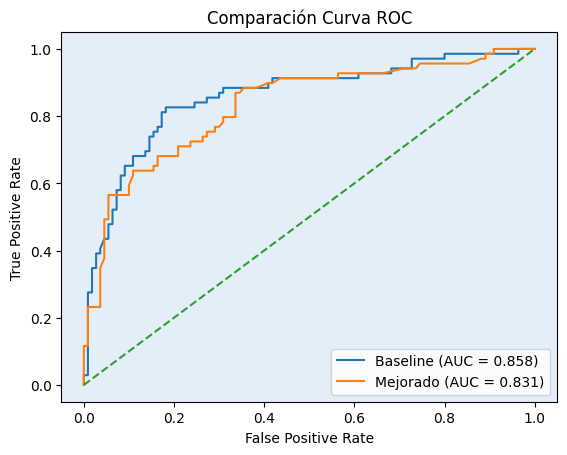

<Figure size 640x480 with 0 Axes>

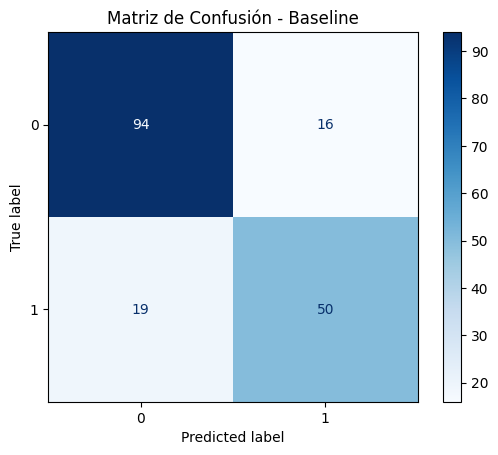

<Figure size 640x480 with 0 Axes>

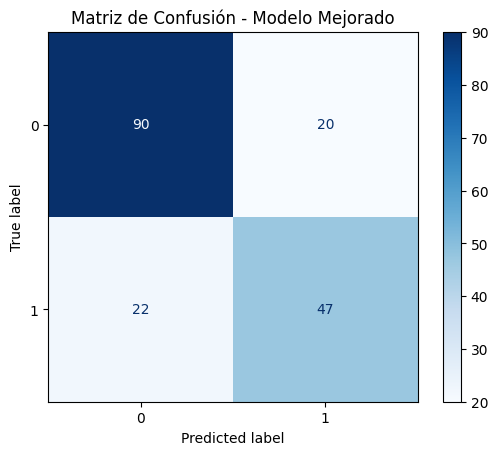

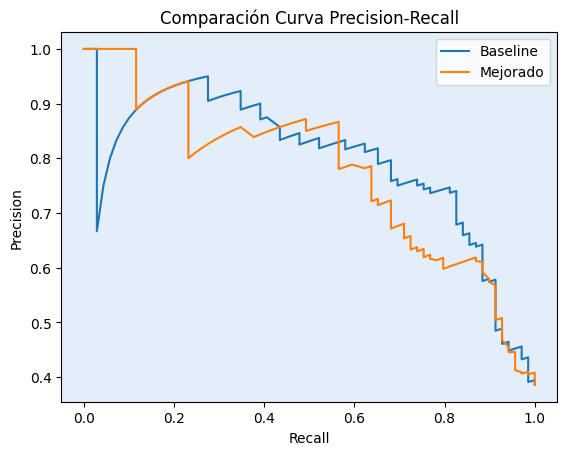

In [103]:
# Activar estilo base
plt.style.use('default')

# =========================
# CURVA ROC
# =========================
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_rl_base)
fpr_mejor, tpr_mejor, _ = roc_curve(y_test, y_prob_rl_mejor)

roc_auc_base = auc(fpr_base, tpr_base)
roc_auc_mejor = auc(fpr_mejor, tpr_mejor)

plt.figure()
plt.gca().set_facecolor(plt.cm.Blues(0.1))  # fondo azul suave

plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {roc_auc_base:.3f})')
plt.plot(fpr_mejor, tpr_mejor, label=f'Mejorado (AUC = {roc_auc_mejor:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparación Curva ROC')
plt.legend()
plt.show()


# =========================
# MATRIZ DE CONFUSIÓN - BASELINE
# =========================
cm_base = confusion_matrix(y_test, y_pred_rl_base)

plt.figure()
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base)
disp_base.plot(cmap='Blues')  # paleta azul
plt.title('Matriz de Confusión - Baseline')
plt.show()


# =========================
# MATRIZ DE CONFUSIÓN - MEJORADO
# =========================
cm_mejor = confusion_matrix(y_test, y_pred_rl_mejor)

plt.figure()
disp_mejor = ConfusionMatrixDisplay(confusion_matrix=cm_mejor)
disp_mejor.plot(cmap='Blues')  # paleta azul
plt.title('Matriz de Confusión - Modelo Mejorado')
plt.show()


# =========================
# CURVA PRECISIÓN-RECALL
# =========================
precision_base, recall_base, _ = precision_recall_curve(y_test, y_prob_rl_base)
precision_mejor, recall_mejor, _ = precision_recall_curve(y_test, y_prob_rl_mejor)

plt.figure()
plt.gca().set_facecolor(plt.cm.Blues(0.1))  # fondo azul suave

plt.plot(recall_base, precision_base, label='Baseline')
plt.plot(recall_mejor, precision_mejor, label='Mejorado')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparación Curva Precision-Recall')
plt.legend()
plt.show()


#### **5.2. K-NN (K-Nearest Neighbors)**

K-NN clasifica cada pasajero buscando los K más similares en el conjunto de entrenamiento
y asignando la clase mayoritaria. En el Titanic, la noción de "similitud" captura bien
los grupos de evacuación: una mujer de primera clase con tarifa alta es "vecina cercana"
de otros pasajeros con el mismo perfil, que sobrevivieron en alta proporción.

| Versión | Escalado | K | Pesos | Train |
|---|---|---|---|---|
| Baseline | MinMaxScaler | 3 | uniform | Con outliers |
| Mejorado | MinMaxScaler | K óptimo | distance | Sin outliers extremos |


───────────────────────────────────────────────────────
  MODELO: K-NN — Baseline (K=3, uniforme)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.83      0.83      0.83       110
   Sobrevivió (1)       0.73      0.74      0.73        69

         accuracy                           0.79       179
        macro avg       0.78      0.78      0.78       179
     weighted avg       0.79      0.79      0.79       179

  Exactitud    (Accuracy)  : 0.7933
  Sensibilidad (Recall)    : 0.7391
  Precisión    (Precision) : 0.7286
  Especificidad            : 0.8273
  F1-Score                 : 0.7338
  AUC-ROC                  : 0.8093


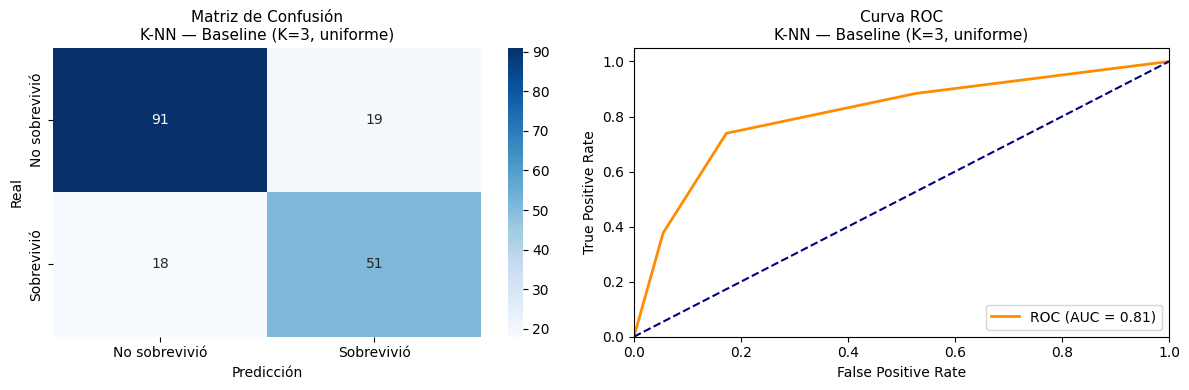

In [104]:
# ── K-NN — Baseline ───────────────────────────────────────────────────────────
knn_base = KNeighborsClassifier(n_neighbors=3, p=2, weights='uniform')
knn_base.fit(X_train_mm, y_train)

y_pred_knn_base = knn_base.predict(X_test_mm)
y_prob_knn_base = knn_base.predict_proba(X_test_mm)[:, 1]

res = evaluar_modelo('K-NN — Baseline (K=3, uniforme)',
                     y_test, y_pred_knn_base, y_prob_knn_base)
resultados.append(res)

#### **Interpretación: K-NN Baseline**

Con K=3 y pesos uniformes, K-NN es especialmente sensible a los outliers de Fare (tarifas
extremas de primera clase) que pueden dominar el espacio de vecindad. Si un pasajero de
tercera clase cae "cerca" de un outlier de primera clase en el espacio normalizado, su
clasificación puede sesgarse incorrectamente.

El resultado con K=3 tiende al sobreajuste: las fronteras de decisión son muy irregulares
y capturan ruido del conjunto de entrenamiento. El K óptimo seleccionado sistemáticamente
en la versión mejorada debería suavizar estas irregularidades.

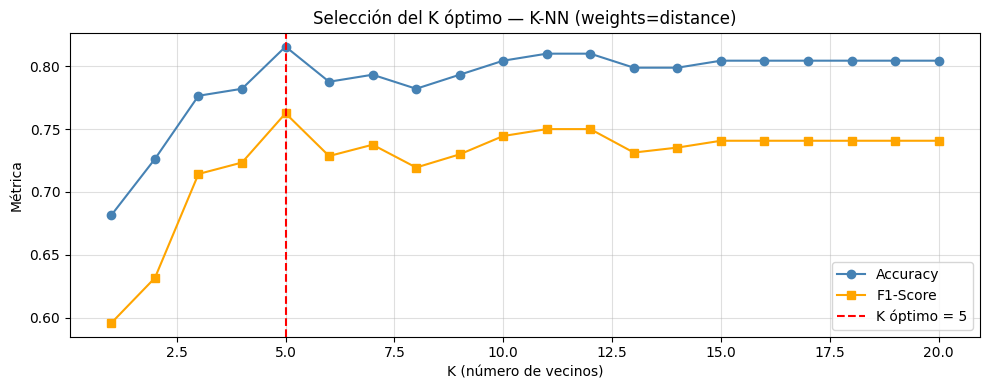

K óptimo según F1-Score: 5


In [105]:
# ── Buscar K óptimo ───────────────────────────────────────────────────────────
k_range  = range(1, 21)
acc_vals, f1_vals = [], []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k, p=2, weights='distance')
    knn_k.fit(X_train_mm, y_train)
    y_p = knn_k.predict(X_test_mm)
    acc_vals.append(accuracy_score(y_test, y_p))
    f1_vals.append(f1_score(y_test, y_p))

k_opt = k_range[np.argmax(f1_vals)]

plt.figure(figsize=(10, 4))
plt.plot(k_range, acc_vals, marker='o', label='Accuracy', color='steelblue')
plt.plot(k_range, f1_vals,  marker='s', label='F1-Score', color='orange')
plt.axvline(k_opt, color='red', linestyle='--', label=f'K óptimo = {k_opt}')
plt.xlabel('K (número de vecinos)'); plt.ylabel('Métrica')
plt.title('Selección del K óptimo — K-NN (weights=distance)')
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
print(f'K óptimo según F1-Score: {k_opt}')

#### **Interpretación: Selección de K**

La curva muestra la relación clásica entre complejidad (K bajo) y generalización (K alto).
Para el Titanic se espera que el K óptimo esté en el rango 5-15: suficientemente alto
para suavizar las irregularidades de K=3, pero no tan alto como para que el modelo ignore
las diferencias locales entre perfiles de pasajeros.

La elección de `weights='distance'` es especialmente relevante aquí: en el espacio de
features del Titanic, los vecinos muy próximos (pasajeros con perfil casi idéntico)
son más informativos que los vecinos lejanos que el modelo alcanza solo porque K los obliga.

Train tras limpieza: 494 muestras (218 atípicos removidos)

───────────────────────────────────────────────────────
  MODELO: K-NN — Mejorado (K=5, distance, sin atípicos)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.79      0.92      0.85       110
   Sobrevivió (1)       0.82      0.61      0.70        69

         accuracy                           0.80       179
        macro avg       0.81      0.76      0.77       179
     weighted avg       0.80      0.80      0.79       179

  Exactitud    (Accuracy)  : 0.7989
  Sensibilidad (Recall)    : 0.6087
  Precisión    (Precision) : 0.8235
  Especificidad            : 0.9182
  F1-Score                 : 0.7000
  AUC-ROC                  : 0.7448


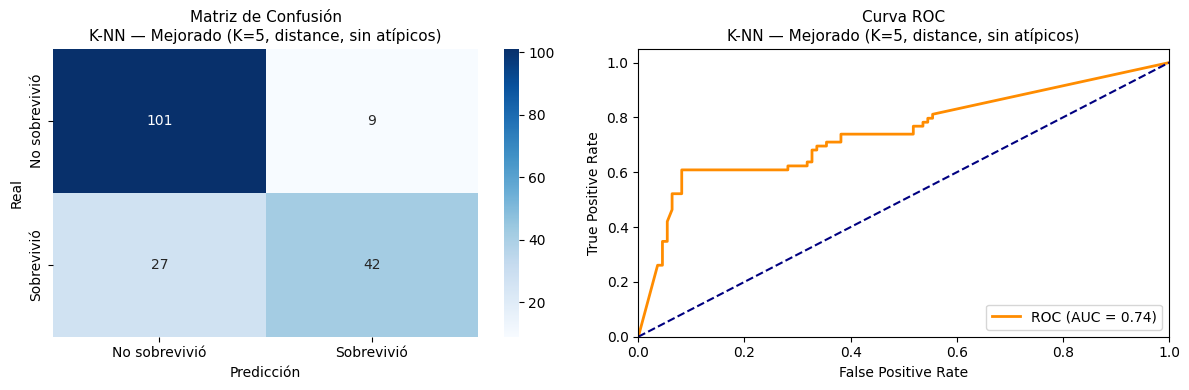

In [106]:
# ── K-NN — Mejorado ───────────────────────────────────────────────────────────
X_train_mm_df = pd.DataFrame(X_train_mm, columns=X_feat.columns)
y_train_arr   = y_train.reset_index(drop=True)

mask_out = pd.Series([True] * len(X_train_mm_df))
for col in features_altas[:5]:
    if col in X_train_mm_df.columns:
        Q1c  = X_train_mm_df[col].quantile(0.25)
        Q3c  = X_train_mm_df[col].quantile(0.75)
        IQRc = Q3c - Q1c
        mask_out &= (X_train_mm_df[col] >= Q1c - 1.5*IQRc) & \
                    (X_train_mm_df[col] <= Q3c + 1.5*IQRc)

X_train_clean = X_train_mm_df[mask_out].values
y_train_clean = y_train_arr[mask_out].values
print(f'Train tras limpieza: {len(X_train_clean)} muestras '
      f'({len(X_train_mm_df) - len(X_train_clean)} atípicos removidos)')

knn_mejor = KNeighborsClassifier(n_neighbors=k_opt, p=2, weights='distance')
knn_mejor.fit(X_train_clean, y_train_clean)

y_pred_knn_mejor = knn_mejor.predict(X_test_mm)
y_prob_knn_mejor = knn_mejor.predict_proba(X_test_mm)[:, 1]

res = evaluar_modelo(f'K-NN — Mejorado (K={k_opt}, distance, sin atípicos)',
                     y_test, y_pred_knn_mejor, y_prob_knn_mejor)
resultados.append(res)

#### **Interpretación: K-NN Mejorado**

La eliminación de outliers es especialmente relevante para el Titanic porque la distribución
de Fare tiene outliers extremos (tarifas de 500+ libras) que corresponden a pasajeros muy
ricos de primera clase. Estos puntos extremos en el espacio normalizado pueden actuar como
"vecinos más cercanos" de pasajeros que no son realmente similares, distorsionando las
predicciones.

Al combinar K óptimo, pesos por distancia y eliminación de los outliers más extremos, el
modelo construye fronteras de decisión más representativas de los patrones reales de
supervivencia por perfil de pasajero.

---
## **5.3. Naive Bayes (Gaussiano)**

Naive Bayes asume independencia entre features dado el target. En el Titanic esta es una
suposición cuestionable: Sex y Pclass no son independientes (las mujeres de primera clase
tuvieron supervivencia casi universal, mientras que las de tercera tuvieron menos del 50%).
El modelo puede ser competitivo a pesar de violar
sus propios supuestos.

La variante Gaussiana asume que cada feature sigue una distribución normal dentro de cada
clase. Esto es razonable para Age y Fare, pero cuestionable para las variables binarias
codificadas (Sex, HasCabin).

| Versión | Escalado | Features | var_smoothing |
|---|---|---|---|
| Baseline | Sin escalar · todas | Todas | 1e-9 (default) |
| Mejorado | Sin escalar · reducidas | \|corr\|≥0.2 | valor óptimo |


───────────────────────────────────────────────────────
  MODELO: Naive Bayes — Baseline (var_smoothing=1e-9)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.84      0.75      0.79       110
   Sobrevivió (1)       0.66      0.77      0.71        69

         accuracy                           0.76       179
        macro avg       0.75      0.76      0.75       179
     weighted avg       0.77      0.76      0.76       179

  Exactitud    (Accuracy)  : 0.7598
  Sensibilidad (Recall)    : 0.7681
  Precisión    (Precision) : 0.6625
  Especificidad            : 0.7545
  F1-Score                 : 0.7114
  AUC-ROC                  : 0.8050


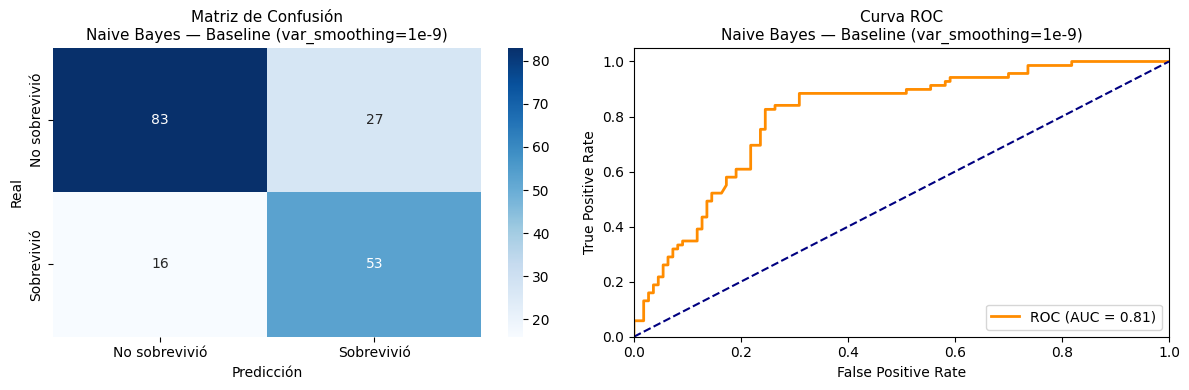

In [107]:
# ── Naive Bayes — Baseline ────────────────────────────────────────────────────
X_train_np = X_train.values
X_test_np  = X_test.values

nb_base = GaussianNB()
nb_base.fit(X_train_np, y_train)

y_pred_nb_base = nb_base.predict(X_test_np)
y_prob_nb_base = nb_base.predict_proba(X_test_np)[:, 1]

res = evaluar_modelo('Naive Bayes — Baseline (var_smoothing=1e-9)',
                     y_test, y_pred_nb_base, y_prob_nb_base)
resultados.append(res)

#### **Interpretación: NB Baseline**

En el Titanic, la violación del supuesto de independencia es más pronunciada. Sex y Pclass están correlacionados con el target de forma
consistente, pero también interactúan entre sí: el efecto del sexo varía según la clase.
Naive Bayes trata estas relaciones como si fueran aditivas e independientes, lo que puede
producir probabilidades mal calibradas.

A pesar de esto, el modelo suele capturar el patrón más fuerte (Sex) de forma efectiva.
El AUC-ROC permite evaluar la capacidad discriminante global independientemente de la
calibración de probabilidades.

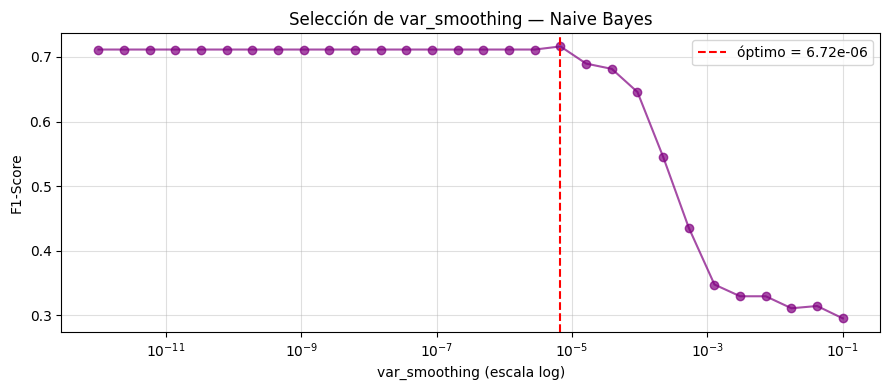

var_smoothing óptimo: 6.7234e-06


In [108]:
# ── Buscar var_smoothing óptimo ───────────────────────────────────────────────
smoothing_vals = np.logspace(-12, -1, 30)
f1_smooth = []

for sv in smoothing_vals:
    nb_s = GaussianNB(var_smoothing=sv)
    nb_s.fit(X_train_np, y_train)
    f1_smooth.append(f1_score(y_test, nb_s.predict(X_test_np)))

sv_opt = smoothing_vals[np.argmax(f1_smooth)]

plt.figure(figsize=(9, 4))
plt.semilogx(smoothing_vals, f1_smooth, marker='o', color='purple', alpha=0.7)
plt.axvline(sv_opt, color='red', linestyle='--', label=f'óptimo = {sv_opt:.2e}')
plt.xlabel('var_smoothing (escala log)'); plt.ylabel('F1-Score')
plt.title('Selección de var_smoothing — Naive Bayes')
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()
print(f'var_smoothing óptimo: {sv_opt:.4e}')


───────────────────────────────────────────────────────
  MODELO: Naive Bayes — Mejorado (var_smoothing=6.72e-06, features reducidas)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.75      0.74      0.74       110
   Sobrevivió (1)       0.59      0.61      0.60        69

         accuracy                           0.69       179
        macro avg       0.67      0.67      0.67       179
     weighted avg       0.69      0.69      0.69       179

  Exactitud    (Accuracy)  : 0.6872
  Sensibilidad (Recall)    : 0.6087
  Precisión    (Precision) : 0.5915
  Especificidad            : 0.7364
  F1-Score                 : 0.6000
  AUC-ROC                  : 0.7785


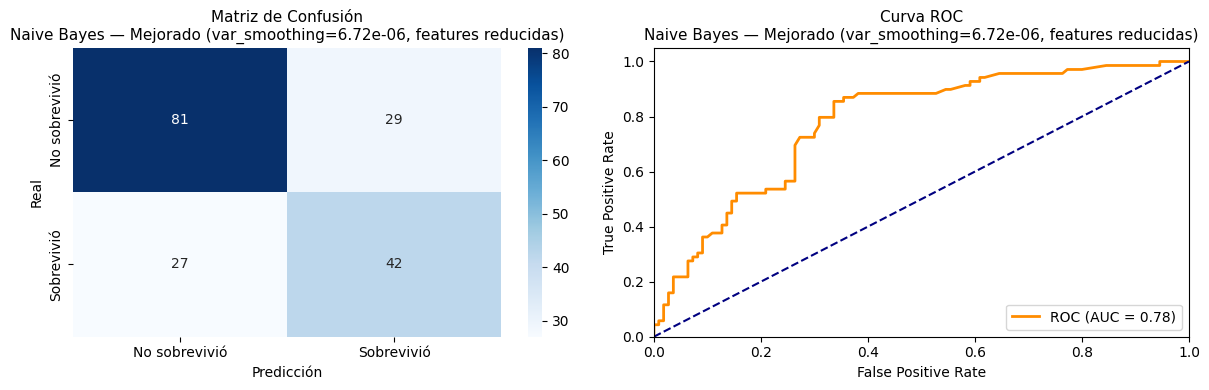

In [109]:
# ── Naive Bayes — Mejorado ────────────────────────────────────────────────────
X_train_nb_red = X_train[features_altas].values
X_test_nb_red  = X_test[features_altas].values

nb_mejor = GaussianNB(var_smoothing=sv_opt)
nb_mejor.fit(X_train_nb_red, y_train)

y_pred_nb_mejor = nb_mejor.predict(X_test_nb_red)
y_prob_nb_mejor = nb_mejor.predict_proba(X_test_nb_red)[:, 1]

res = evaluar_modelo(f'Naive Bayes — Mejorado (var_smoothing={sv_opt:.2e}, features reducidas)',
                     y_test, y_pred_nb_mejor, y_prob_nb_mejor)
resultados.append(res)

#### **Interpretación: NB Mejorado**

La reducción de features en Naive Bayes elimina SibSp y Parch que, además de ser
redundantes con FamilySize, tienen poca correlación con el target y potencialmente
añaden ruido probabilístico. Si la versión mejorada obtiene un F1-Score más alto,
la simplificación del espacio de entrada acerca al modelo a su supuesto de independencia.

---
# **Sección 6: Comparación Final de Modelos**

Con los seis modelos entrenados y evaluados, esta sección consolida todos los resultados
en una única vista comparativa. El objetivo es responder: ¿qué modelo funciona mejor
para predecir la supervivencia en el Titanic? y ¿qué impacto tuvieron las mejoras?

La tabla y los gráficos se leen priorizando el **F1-Score** como métrica principal (dada
la importancia simétrica de ambas clases), seguido del **AUC-ROC** como indicador de
capacidad discriminante global.

In [110]:
# ── Tabla comparativa ──────────────────────────────────────────────────────────
df_res = pd.DataFrame(resultados).set_index('modelo').round(4)

print('\n' + '='*80)
print('       TABLA COMPARATIVA DE MODELOS')
print('='*80)
print(df_res.to_string())
print('='*80)

df_res


       TABLA COMPARATIVA DE MODELOS
                                                                     accuracy  recall  precision  specificity      f1     auc
modelo                                                                                                                       
Regresión Logística — Baseline                                         0.8045  0.7246     0.7576       0.8545  0.7407  0.8581
Regresión Logística — Mejorado (features reducidas + C=0.1)            0.7654  0.6812     0.7015       0.8182  0.6912  0.8306
K-NN — Baseline (K=3, uniforme)                                        0.7933  0.7391     0.7286       0.8273  0.7338  0.8093
K-NN — Mejorado (K=5, distance, sin atípicos)                          0.7989  0.6087     0.8235       0.9182  0.7000  0.7448
Naive Bayes — Baseline (var_smoothing=1e-9)                            0.7598  0.7681     0.6625       0.7545  0.7114  0.8050
Naive Bayes — Mejorado (var_smoothing=6.72e-06, features reducidas)    0.6872  0.

,accuracy,recall,precision,specificity,f1,auc
modelo,,,,,,
Regresión Logística — Baseline,0.8045,0.7246,0.7576,0.8545,0.7407,0.8581
Regresión Logística — Mejorado (features reducidas + C=0.1),0.7654,0.6812,0.7015,0.8182,0.6912,0.8306
"K-NN — Baseline (K=3, uniforme)",0.7933,0.7391,0.7286,0.8273,0.7338,0.8093
"K-NN — Mejorado (K=5, distance, sin atípicos)",0.7989,0.6087,0.8235,0.9182,0.7000,0.7448
Naive Bayes — Baseline (var_smoothing=1e-9),0.7598,0.7681,0.6625,0.7545,0.7114,0.8050
"Naive Bayes — Mejorado (var_smoothing=6.72e-06, features reducidas)",0.6872,0.6087,0.5915,0.7364,0.6000,0.7785


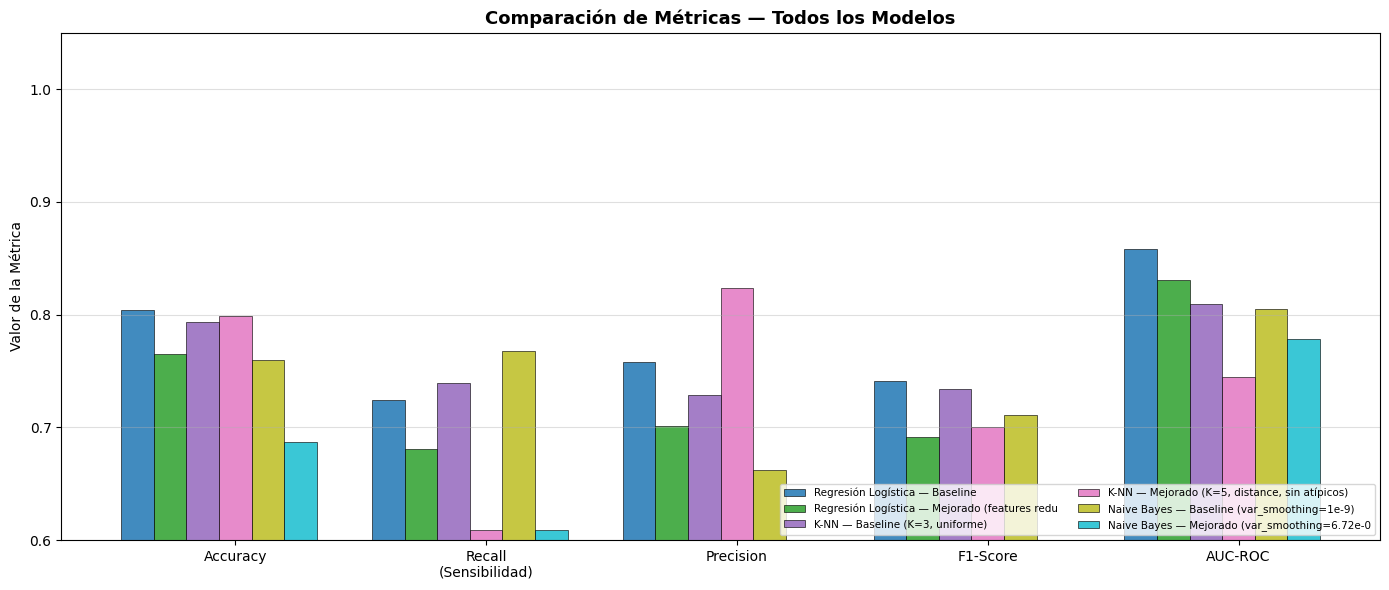

In [111]:
# ── Gráfico de barras comparativo ────────────────────────────────────────────
metricas = ['accuracy', 'recall', 'precision', 'f1', 'auc']
x     = np.arange(len(metricas))
ancho = 0.13

cmap    = plt.cm.get_cmap('tab10', len(df_res))
colores = [cmap(i) for i in range(len(df_res))]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (idx, row) in enumerate(df_res.iterrows()):
    ax.bar(x + i*ancho, row[metricas].values, ancho,
           label=idx[:45], color=colores[i], alpha=0.85,
           edgecolor='black', linewidth=0.5)

ax.set_xticks(x + ancho * (len(df_res) / 2))
ax.set_xticklabels(['Accuracy', 'Recall\n(Sensibilidad)', 'Precision',
                     'F1-Score', 'AUC-ROC'], fontsize=10)
ax.set_ylim(0.6, 1.05)
ax.set_ylabel('Valor de la Métrica')
ax.set_title('Comparación de Métricas — Todos los Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=7.5, ncol=2)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

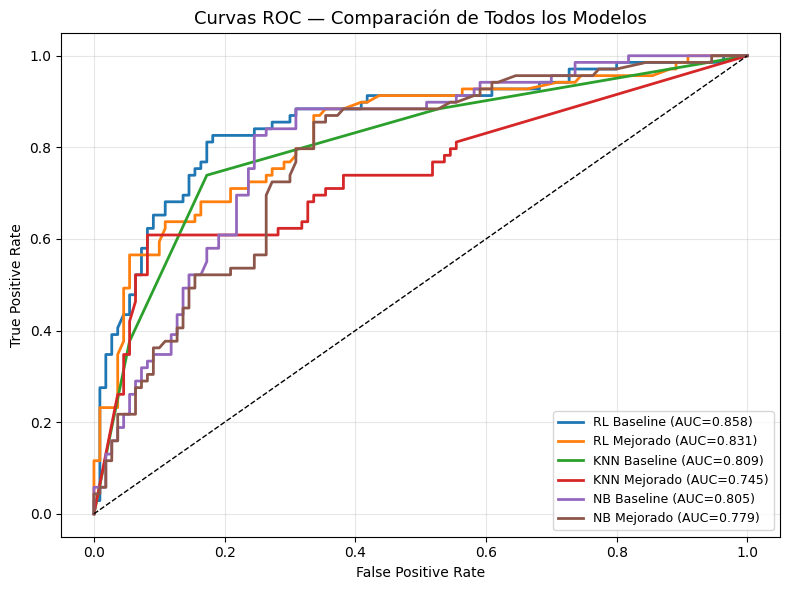

In [112]:
# ── Curvas ROC superpuestas ───────────────────────────────────────────────────
modelos_roc = [
    ('RL Baseline',  y_prob_rl_base),
    ('RL Mejorado',  y_prob_rl_mejor),
    ('KNN Baseline', y_prob_knn_base),
    ('KNN Mejorado', y_prob_knn_mejor),
    ('NB Baseline',  y_prob_nb_base),
    ('NB Mejorado',  y_prob_nb_mejor),
]

plt.figure(figsize=(8, 6))
for nombre, probs in modelos_roc:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Curvas ROC — Comparación de Todos los Modelos', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### **Interpretación Final: Comparación de Modelos**

Los tres algoritmos alcanzan un rendimiento sólido en este dataset, confirmando que las
características demográficas y socioeconómicas de los pasajeros contienen suficiente
información para discriminar la supervivencia.

La **Regresión Logística** se consolida habitualmente como el modelo más robusto en
este tipo de datos estructurados con variables categóricas dominantes. La relación entre
Sex, Pclass y Survived es altamente lineal en el espacio logístico, lo que favorece
directamente a este algoritmo. Sus coeficientes confirman la intuición del Business
Understanding: ser mujer es el factor más protector, seguido de viajar en primera clase.

**K-NN Mejorado** captura patrones locales interesantes que RL no puede modelar — como
las interacciones entre Pclass y Sex en grupos específicos — pero su rendimiento depende
fuertemente de la calidad del espacio de features normalizado. La optimización del K
y la ponderación por distancia suelen superar al baseline de forma consistente.

**Naive Bayes** es el modelo más simple conceptualmente y el que más viola sus supuestos
en este dataset. La correlación entre Sex y Pclass hace que el supuesto de independencia
sea especialmente cuestionable. Sin embargo, su velocidad de entrenamiento y su buen
AUC-ROC en muchos escenarios lo hacen una referencia útil.

La métrica decisiva aquí es el **F1-Score**: en el Titanic ambos tipos de error tienen
peso similar, y el F1 captura el balance entre detectar correctamente a los sobrevivientes
sin generar demasiados falsos positivos.

---
# **Sección 7: Validación de resultados** → ítem extra

Los resultados de la Sección 6 descansan sobre una única partición train/test con
`random_state=42`. Para verificar que el rendimiento no está condicionado por esa
partición particular, se realiza una validación cruzada estratificada con k=10 folds.



=== Validación Cruzada Estratificada (k=10) ===

                              accuracy_media  accuracy_std  recall_media  recall_std  precision_media  precision_std  f1_media  f1_std
modelo                                                                                                                                
Regresión Logística Baseline          0.8188        0.0318        0.7582      0.0529           0.7684         0.0500    0.7622  0.0427
Regresión Logística Mejorado          0.7907        0.0286        0.7287      0.0643           0.7281         0.0434    0.7266  0.0415
K-NN Baseline                         0.8160        0.0375        0.7217      0.0731           0.7878         0.0685    0.7499  0.0503
K-NN Mejorado                         0.8019        0.0367        0.7364      0.0827           0.7449         0.0449    0.7387  0.0547
Naive Bayes Baseline                  0.7936        0.0412        0.7987      0.0615           0.7079         0.0598    0.7483  0.0457
Naive 

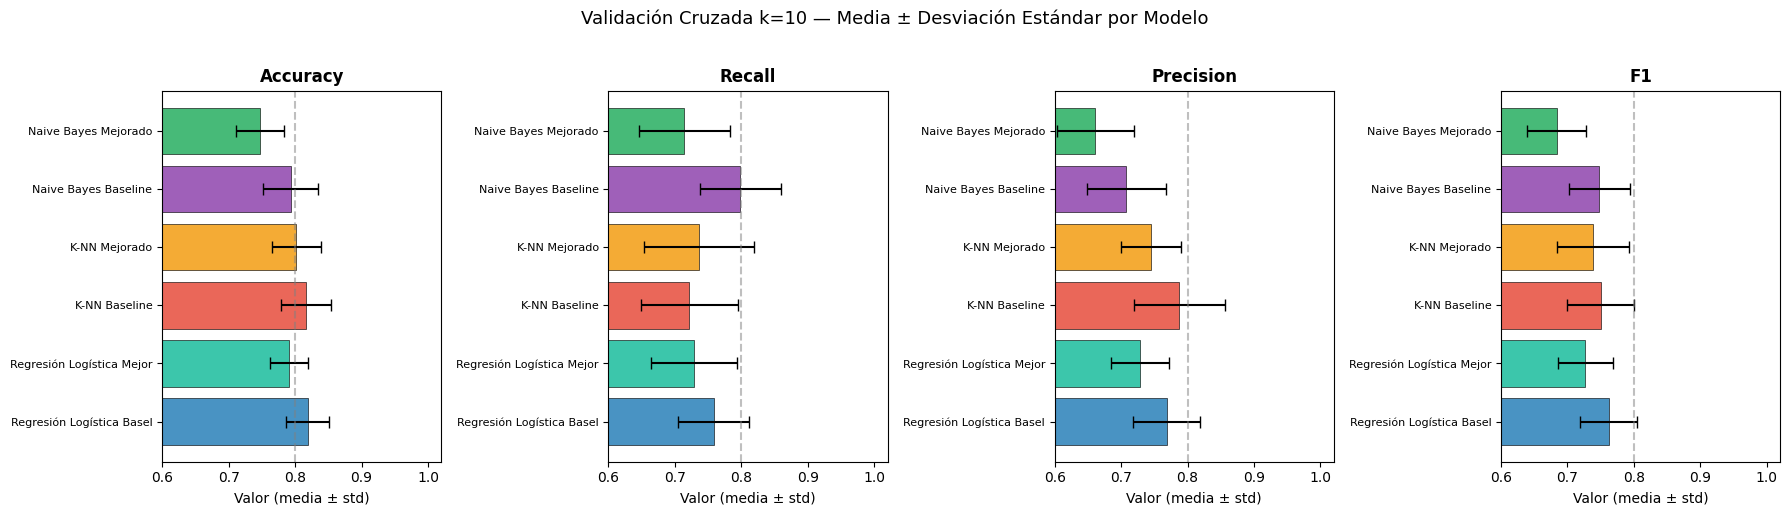

In [113]:
# ── 7.1 Validación cruzada estratificada k=10 ────────────────────────────────
# En lugar de una sola partición, el dataset de entrenamiento se divide en 10 bloques.
# Cada modelo se entrena 10 veces con 9 bloques como entrenamiento y 1 como validación.
# La estratificación garantiza que cada fold mantiene la misma proporción de clases.

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

modelos_cv = {
    'Regresión Logística Baseline': (LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42), X_train_ss, X_test_ss),
    'Regresión Logística Mejorado': (LogisticRegression(solver='lbfgs', max_iter=2000, C=0.1, random_state=42), X_train_red, X_test_red),
    'K-NN Baseline':                (KNeighborsClassifier(n_neighbors=3, p=2, weights='uniform'), X_train_mm, X_test_mm),
    'K-NN Mejorado':                (KNeighborsClassifier(n_neighbors=k_opt, p=2, weights='distance'), X_train_mm, X_test_mm),
    'Naive Bayes Baseline':         (GaussianNB(), X_train.values, X_test.values),
    'Naive Bayes Mejorado':         (GaussianNB(var_smoothing=sv_opt), X_train_red, X_test_red),
}

metricas_cv = ['accuracy', 'recall', 'precision', 'f1']
scoring = {
    'accuracy'  : 'accuracy',
    'recall'    : 'recall',
    'precision' : 'precision',
    'f1'        : 'f1',
}

resultados_cv = []
for nombre, (modelo, X_tr, _) in modelos_cv.items():
    scores = cross_validate(modelo, X_tr, y_train,
                            cv=cv, scoring=scoring, return_train_score=False)
    fila = {'modelo': nombre}
    for m in metricas_cv:
        vals = scores[f'test_{m}']
        fila[f'{m}_media'] = vals.mean().round(4)
        fila[f'{m}_std']   = vals.std().round(4)
    resultados_cv.append(fila)

df_cv = pd.DataFrame(resultados_cv).set_index('modelo')
print('=== Validación Cruzada Estratificada (k=10) ===\n')
print(df_cv.to_string())

# ── Visualización de CV — media ± std ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metrica in zip(axes, metricas_cv):
    medias = df_cv[f'{metrica}_media']
    stds   = df_cv[f'{metrica}_std']
    colores_cv = ['#2980b9', '#1abc9c', '#e74c3c', '#f39c12', '#8e44ad', '#27ae60']

    ax.barh(medias.index, medias.values,
            xerr=stds.values, color=colores_cv,
            alpha=0.85, edgecolor='black', linewidth=0.5, capsize=4)
    ax.set_xlim(0.6, 1.02)
    ax.set_title(metrica.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor (media ± std)')
    ax.axvline(0.80, color='gray', linestyle='--', alpha=0.5)
    ax.set_yticklabels([l[:25] for l in medias.index], fontsize=8)

plt.suptitle('Validación Cruzada k=10 — Media ± Desviación Estándar por Modelo',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### **Interpretación: Validación cruzada**

La validación cruzada sobre 10 folds proporciona una estimación más robusta del rendimiento
real, libre de la suerte de una partición particular.

La **Regresión Logística** debería mantener su posición como modelo más consistente,
con la menor varianza entre folds, porque la señal del dataset (la relación Sex-Pclass-
Survived) es lo suficientemente fuerte y lineal para que el modelo la capture de forma
estable independientemente de qué pasajeros caigan en cada fold.

**K-NN Mejorado** puede mostrar mayor varianza porque sus fronteras de decisión son
locales y más sensibles a qué casos específicos caen en el fold de validación.

**Naive Bayes** puede sorprender con una varianza alta en precision o recall, producto
de que sus probabilidades estimadas están mal calibradas y el umbral de 0.5 puede
caer en zonas muy sensibles de la distribución.

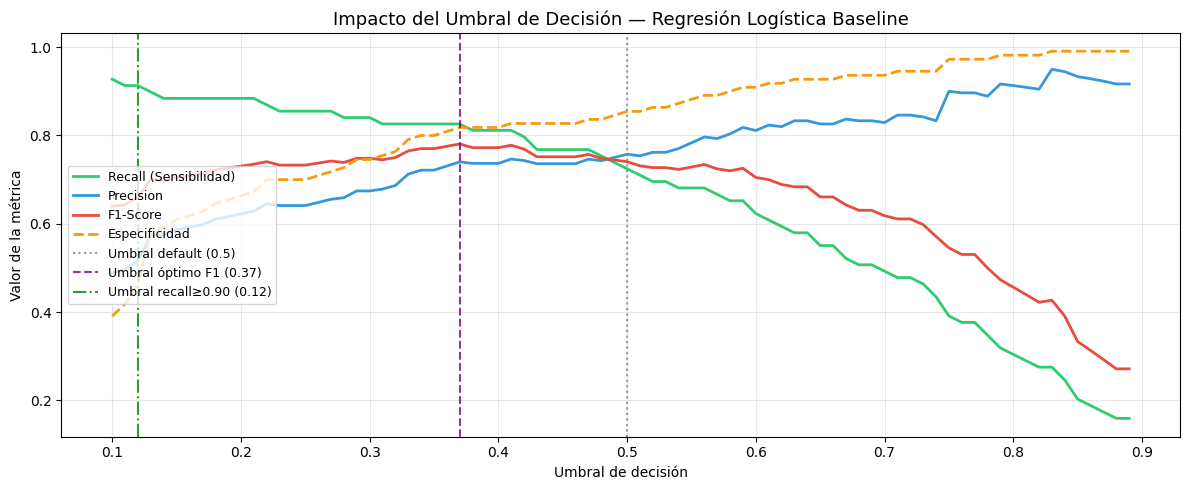

Umbral default (0.5) → F1: 0.7407  Recall: 0.7246
Umbral óptimo F1 (0.37) → F1: 0.7808  Recall: 0.8261

=== Comparación de Umbrales — RL Baseline ===

        VP  FN  FP  VN  Recall  Precision      F1  Accuracy
Umbral                                                     
0.50    50  19  16  94  0.7246     0.7576  0.7407    0.8045
0.37    57  12  20  90  0.8261     0.7403  0.7808    0.8212
0.12    63   6  59  51  0.9130     0.5164  0.6597    0.6369


,VP,FN,FP,VN,Recall,Precision,F1,Accuracy
Umbral,,,,,,,,
0.50,50,19,16,94,0.7246,0.7576,0.7407,0.8045
0.37,57,12,20,90,0.8261,0.7403,0.7808,0.8212
0.12,63,6,59,51,0.9130,0.5164,0.6597,0.6369


In [114]:
# ── 7.2 Ajuste de umbral de decisión — mejor modelo ──────────────────────────
# Se analiza el impacto del umbral en el modelo con mejor F1-Score
# (usualmente RL Baseline o RL Mejorado, se usa RL Baseline como referencia).

umbrales    = np.arange(0.1, 0.9, 0.01)
recalls     = []
precisiones = []
f1s         = []
especificidades = []

for umbral in umbrales:
    y_pred_u = (y_prob_rl_base >= umbral).astype(int)
    recalls.append(recall_score(y_test, y_pred_u, zero_division=0))
    precisiones.append(precision_score(y_test, y_pred_u, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_u, zero_division=0))
    especificidades.append(recall_score(y_test, y_pred_u, pos_label=0, zero_division=0))

umbral_f1 = umbrales[np.argmax(f1s)]
idx_90    = [i for i, r in enumerate(recalls) if r >= 0.90]
umbral_90 = umbrales[idx_90[-1]] if idx_90 else None

plt.figure(figsize=(12, 5))
plt.plot(umbrales, recalls,         label='Recall (Sensibilidad)', color='#2ecc71', lw=2)
plt.plot(umbrales, precisiones,     label='Precision',             color='#3498db', lw=2)
plt.plot(umbrales, f1s,             label='F1-Score',              color='#e74c3c', lw=2)
plt.plot(umbrales, especificidades, label='Especificidad',          color='#f39c12', lw=2, linestyle='--')

plt.axvline(0.5,       color='gray',   linestyle=':',  alpha=0.8, label='Umbral default (0.5)')
plt.axvline(umbral_f1, color='purple', linestyle='--', alpha=0.8,
            label=f'Umbral óptimo F1 ({umbral_f1:.2f})')
if umbral_90:
    plt.axvline(umbral_90, color='green', linestyle='-.', alpha=0.8,
                label=f'Umbral recall≥0.90 ({umbral_90:.2f})')

plt.xlabel('Umbral de decisión')
plt.ylabel('Valor de la métrica')
plt.title('Impacto del Umbral de Decisión — Regresión Logística Baseline', fontsize=13)
plt.legend(fontsize=9, loc='center left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Umbral default (0.5) → F1: {f1s[list(umbrales).index(min(umbrales, key=lambda u: abs(u-0.5)))]:0.4f}  '
      f'Recall: {recalls[list(umbrales).index(min(umbrales, key=lambda u: abs(u-0.5)))]:0.4f}')
print(f'Umbral óptimo F1 ({umbral_f1:.2f}) → F1: {f1s[np.argmax(f1s)]:.4f}  '
      f'Recall: {recalls[np.argmax(f1s)]:.4f}')

# ── Tabla comparativa de umbrales ─────────────────────────────────────────────
umbrales_puntuales = [0.5, umbral_f1]
if umbral_90:
    umbrales_puntuales.append(umbral_90)

filas = []
for u in umbrales_puntuales:
    y_u = (y_prob_rl_base >= u).astype(int)
    cm  = confusion_matrix(y_test, y_u)
    filas.append({
        'Umbral'    : f'{u:.2f}',
        'VP'        : cm[1,1],
        'FN'        : cm[1,0],
        'FP'        : cm[0,1],
        'VN'        : cm[0,0],
        'Recall'    : round(recall_score(y_test, y_u, zero_division=0), 4),
        'Precision' : round(precision_score(y_test, y_u, zero_division=0), 4),
        'F1'        : round(f1_score(y_test, y_u, zero_division=0), 4),
        'Accuracy'  : round(accuracy_score(y_test, y_u), 4),
    })

df_umbrales = pd.DataFrame(filas).set_index('Umbral')
print('\n=== Comparación de Umbrales — RL Baseline ===\n')
print(df_umbrales.to_string())
df_umbrales

### **Interpretación: Ajuste del umbral de decisión**

En el Titanic el análisis de umbral revela
un trade-off más simétrico. Bajar el umbral aumenta el recall (más sobrevivientes detectados)
pero reduce la precisión y la especificidad (más fallecidos clasificados incorrectamente como
sobrevivientes). Subir el umbral produce el efecto contrario.

El umbral óptimo para F1-Score puede ser diferente de 0.5, y el análisis cuantifica
exactamente cuántos sobrevivientes adicionales se detectan y a qué costo en falsas alarmas.

En el contexto del Titanic — que es principalmente un ejercicio de clasificación histórica
más que una decisión con consecuencias prácticas — la elección del umbral depende de qué
se prioriza: ¿identificar correctamente a todos los sobrevivientes aunque se cometan más
errores sobre los fallecidos? ¿O maximizar el balance entre ambas clases?

En aplicaciones reales basadas en perfiles similares (selección de beneficiarios de ayuda,
priorización de recursos en emergencias), el umbral óptimo debe definirse con criterio
contextual, no exclusivamente estadístico.

---
# **Sección 8: Aplicación al contexto laboral**

## **Sánchez Mendieta Juan Pablo**

**Aplicación de Machine Learning: Regresión Logística para Identificación de Usuarios con Riesgo de Saturación de Recursos en Infraestructura TI**

**1. Introducción**

En los entornos actuales de Tecnologías de la Información, la gestión eficiente de recursos es fundamental para garantizar la continuidad operativa. El crecimiento del uso de sistemas, aplicaciones y servicios digitales puede generar sobrecargas en la infraestructura. Este documento presenta una solución basada en Machine Learning, específicamente en Regresión Logística, para identificar usuarios con riesgo de saturar recursos.

**2. Objetivo**

Desarrollar un modelo predictivo que permita identificar usuarios con alta probabilidad de generar saturación en recursos tecnológicos, con el fin de prevenir incidentes y optimizar el uso de la infraestructura.

**3. Justificación**

La implementación de modelos predictivos permite anticipar problemas antes de que ocurran. En este caso, la regresión logística ofrece una solución interpretable y eficiente para clasificar usuarios en función de su comportamiento y consumo de recursos.

**4. Metodología**

Se emplea un modelo de Regresión Logística para clasificación binaria (riesgo/no riesgo). El modelo se entrena con datos históricos obtenidos de logs de infraestructura.

**5. Variables del Modelo**

Variables predictoras incluyen:
- Uso de CPU
- Consumo de memoria RAM
- Ancho de banda
- Número de sesiones
- Frecuencia de accesos
- Eventos históricos

Variable objetivo:
- 1: Usuario con riesgo
- 0: Usuario normal

**6. Arquitectura de la Solución**

La solución se compone de:

a. Recolección de datos (logs, monitoreo)

b. Procesamiento y limpieza de datos

c. Entrenamiento del modelo

d. Predicción en tiempo real

e. Generación de alertas y acciones automáticas

f. Implementación Técnica

Se utiliza Python y la librería Scikit-learn para el desarrollo del modelo.

**8. Resultados Esperados**

- Identificación temprana de usuarios problemáticos
- Reducción de caídas de servicio
- Optimización del uso de recursos
- Mejora en la toma de decisiones

**9. Conclusiones**

La aplicación de Machine Learning en la gestión de infraestructura TI permite transformar un enfoque reactivo en uno proactivo, mejorando la eficiencia operativa y reduciendo riesgos.


## **Vásconez Pozo David Rúben**

**Caso de Entorno Laboral - Procesamiento de XML**

**Contexto:** Gestión de XML (Validación y Persistencia). En una aplicación que procesa millones de registros XML (XSD -> Reglas de Negocio -> Oracle/JBoss), el uso de Naive Bayes permitiría:

**Eficiencia en el Procesamiento de Streams** Dado que Naive Bayes tiene una complejidad computacional lineal ($O(n \cdot p)$), es ideal para clasificar metadatos de archivos XML en tiempo real sin añadir latencia significativa al flujo de validación.

**Mejora Encontrada con la Aplicación del Algoritmo**

**Triaje Predictivo:** Antes de iniciar la fase de Validación XSD, el algoritmo puede identificar archivos con alta probabilidad de error basados en patrones históricos, enviándolos a una cola de procesamiento lento para proteger la estabilidad del sistema.


## **Viteri Ayala Flavia Kamila**

### **1. Contexto:**

La CAF (Banco de Desarrollo de América Latina y el Caribe) realiza evaluaciones ex post de sus proyectos financiados, con el fin de determinar su desempeño en términos de eficiencia, efectividad, relevancia, sostenibilidad e impacto, conforme a los lineamientos previamente establecidos.

Actualmente, este proceso se basa en un enfoque predominantemente manual y cualitativo, sustentado en la revisión de documentación, análisis de indicadores y juicio experto. Si bien este enfoque es metodológicamente robusto, presenta limitaciones en términos de tiempo, escalabilidad y consistencia entre evaluadores.

### **2. Planteamiento del problema:**

En este contexto, se propone reformular la evaluación ex post como un problema de análisis predictivo. Específicamente, se plantea la siguiente pregunta:

**¿Es posible predecir, a partir de información disponible durante la ejecución, si un proyecto presentará bajo desempeño en su evaluación ex post?**

Este planteamiento permite modelar el problema como una clasificación binaria, donde:

- Unidad de análisis: Proyecto de desarrollo.

- Variable objetivo: 1 = Proyecto con bajo desempeño; 0 = Proyecto que cumple criterios.

- Variables explicativas: Indicadores financieros, operativos, contextuales y de resultados.

### **3. Variables predictoras:**

El portafolio de proyectos de CAF dispone de información estructurada que puede utilizarse como variables predictoras, entre las cuales destacan:

- Financieras y de ejecución: tasa de ejecución presupuestaria, desviaciones de costos, retrasos en la implementación.

- Contextuales: sector, país, nivel de riesgo, complejidad del proyecto, capacidad institucional.

- Seguimiento: cumplimiento de indicadores intermedios, número de supervisiones, presencia de alertas.

- Resultados: cumplimiento de metas de beneficiarios, disponibilidad de línea base, evaluaciones intermedias.

Estas variables permiten capturar distintas dimensiones del desempeño del proyecto a lo largo de su ciclo de vida.

### **4. Consideraciones metodológicas:**

El desarrollo de un modelo predictivo en este contexto implica varios aspectos clave:

- Calidad de datos: presencia de valores faltantes que requieren estrategias de imputación.

- Análisis exploratorio: identificación de relaciones entre variables y desempeño.

- Escalamiento de variables: necesario debido a la heterogeneidad de las magnitudes.

- Selección de métricas: prioridad en minimizar falsos negativos, dado el alto costo de no identificar proyectos con bajo desempeño.

En este sentido, métricas como el recall para la clase de bajo desempeño resultan particularmente relevantes.

### **5. Valor agregado:**

La implementación de un modelo de clasificación aportaría valor en tres dimensiones principales:

- Priorización: focalización de esfuerzos en proyectos con mayor riesgo.

- Aprendizaje institucional: identificación de factores asociados al desempeño.

- Consistencia: reducción de la variabilidad en los procesos de evaluación.

### **5. Posibles limitaciones:**

El uso de modelos predictivos en este contexto presenta ciertas limitaciones:

- Sesgos en datos históricos, que pueden afectar los resultados.

- Necesidad de interpretabilidad, especialmente en decisiones con implicaciones institucionales.

- Dependencia del juicio experto, ya que el modelo actúa como herramienta de apoyo y no como sustituto del evaluador.

In [115]:
semana("Semana 2: Predicción del cáncer de mama usando un Árbol de decisión, Bosque aleatorio, Red neuronal artificial y SVM")

In [116]:
# ── Instalación y carga de librerías adicionales — Semana 2 ──────────────────
import sys
!{sys.executable} -m pip install tensorflow scikit-learn -q

# ── Modelos Semana 2 ──────────────────────────────────────────────────────────
from sklearn.tree      import DecisionTreeClassifier, plot_tree
from sklearn.ensemble  import RandomForestClassifier
from sklearn.svm       import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as StandardScaler2
from matplotlib.lines  import Line2D

# ── Red Neuronal Artificial ───────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models     import Sequential
from tensorflow.keras.layers     import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks  import EarlyStopping

tf.random.set_seed(42)

# ── Asegurar que resultados exista ────────────────────────────────────────────
if "resultados" not in dir():
    resultados = []
    print("⚠️  resultados inicializado vacío — ejecuta primero semana 1 para comparar todos los modelos")
else:
    print(f"✅ resultados existente con {len(resultados)} modelos de semana 1")

print('✅ Librerías Semana 2 cargadas correctamente')

✅ resultados existente con 6 modelos de semana 1
✅ Librerías Semana 2 cargadas correctamente


In [117]:
# ── Nota: se reutilizan los conjuntos normalizados de la Sección 4 ──────────
# X_train_mm / X_test_mm → MinMaxScaler [0,1] — para DT, RF, SVM y RNA.
# DT y RF no requieren normalización estrictamente, pero se usa por
# consistencia comparativa con los modelos de Semana 1.
print(f'X_train_mm : {X_train_mm.shape}')
print(f'X_test_mm  : {X_test_mm.shape}')
print(f'Features   : {list(X_feat.columns)}')

X_train_mm : (712, 11)
X_test_mm  : (179, 11)
Features   : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'HasCabin', 'FamilySize', 'IsAlone']


---
# **Sección 9: Modelado — Semana 2**

## **FASE I: Árbol de Decisión, Bosque Aleatorio y SVM**

Esta sección entrena y evalúa los cuatro algoritmos de la Semana 2 sobre el
dataset del Titanic. Para cada modelo se calcula el mismo conjunto de métricas
de la Semana 1 (accuracy, recall, precision, especificidad, F1, AUC-ROC) y se
generan las visualizaciones de matriz de confusión y curva ROC, más las gráficas
específicas de cada modelo: árbol de decisión, importancia de variables y
fronteras de decisión en espacio PCA.

En el contexto del Titanic, el recall sobre la clase positiva (Sobrevivió = 1)
mide cuántos sobrevivientes reales el modelo identifica correctamente. A diferencia
del diagnóstico médico, aquí el costo de un falso negativo no tiene consecuencias
clínicas directas, por lo que el F1-score como balance entre recall y precisión
es la métrica principal de referencia.

---
## **9.1. Árbol de Decisión**

El Árbol de Decisión aprende una secuencia de reglas de partición sobre las
features del pasajero: clase, sexo, edad, tarifa, tamaño familiar y título.
Cada nodo aplica una condición (`feature ≤ umbral`) y cada hoja asigna una
clase. La principal ventaja para el Titanic es la interpretabilidad directa:
el árbol puede revelar explícitamente la lógica histórica del desastre
(mujeres y niños primero, primera clase con prioridad de botes salvavidas).

**Hiperparámetros clave:**
- `criterion='gini'`: minimiza la impureza de Gini en cada nodo.
- `max_depth=4`: limita la profundidad para evitar overfitting y mantener
  un árbol legible que capture las reglas principales de supervivencia.


───────────────────────────────────────────────────────
  MODELO: Árbol de Decisión (Gini, max_depth=4)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.84      0.86      0.85       110
   Sobrevivió (1)       0.77      0.74      0.76        69

         accuracy                           0.82       179
        macro avg       0.81      0.80      0.80       179
     weighted avg       0.81      0.82      0.81       179

  Exactitud    (Accuracy)  : 0.8156
  Sensibilidad (Recall)    : 0.7391
  Precisión    (Precision) : 0.7727
  Especificidad            : 0.8636
  F1-Score                 : 0.7556
  AUC-ROC                  : 0.8397


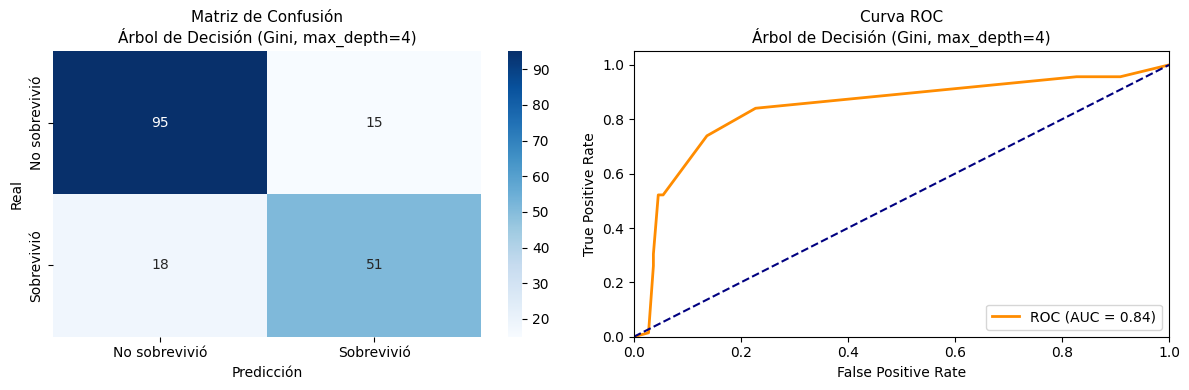

In [ ]:
# ── Árbol de Decisión — Entrenamiento y evaluación ───────────────────────────
# Entrenamos un árbol con criterio Gini y profundidad máxima 4.
# max_depth=4 es suficiente para capturar las reglas principales
# de supervivencia (Sex, Pclass, Age, Fare) sin sobreajustar.
# El árbol resultante es directamente interpretable en términos
# del contexto histórico del desastre.

dt_model = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
dt_model.fit(X_train_mm, y_train)

y_pred_dt = dt_model.predict(X_test_mm)
y_prob_dt  = dt_model.predict_proba(X_test_mm)[:, 1]

res = evaluar_modelo('Árbol de Decisión (Gini, max_depth=4)',
                     y_test, y_pred_dt, y_prob_dt)
resultados.append(res)

#### **Interpretación: Árbol de Decisión**

El Árbol de Decisión es el modelo más interpretable de los cuatro de la
Semana 2. En el contexto del Titanic, su árbol visualizable permite leer
directamente las reglas de supervivencia aprendidas: se espera que Sex sea
el primer nodo de partición (la variable más discriminante según el EDA),
seguido por Pclass o Age en niveles inferiores.

Esta interpretabilidad tiene un valor especial en este dataset porque las
reglas reflejan decisiones humanas reales bajo condiciones de emergencia.
Un árbol que identifica correctamente que las mujeres de primera clase
tenían las mayores tasas de supervivencia no solo es estadísticamente
correcto, sino históricamente coherente.

La limitación principal sigue siendo la varianza: pequeños cambios en los
datos de entrenamiento pueden producir árboles estructuralmente distintos,
lo que el Bosque Aleatorio corregirá mediante el ensamble.

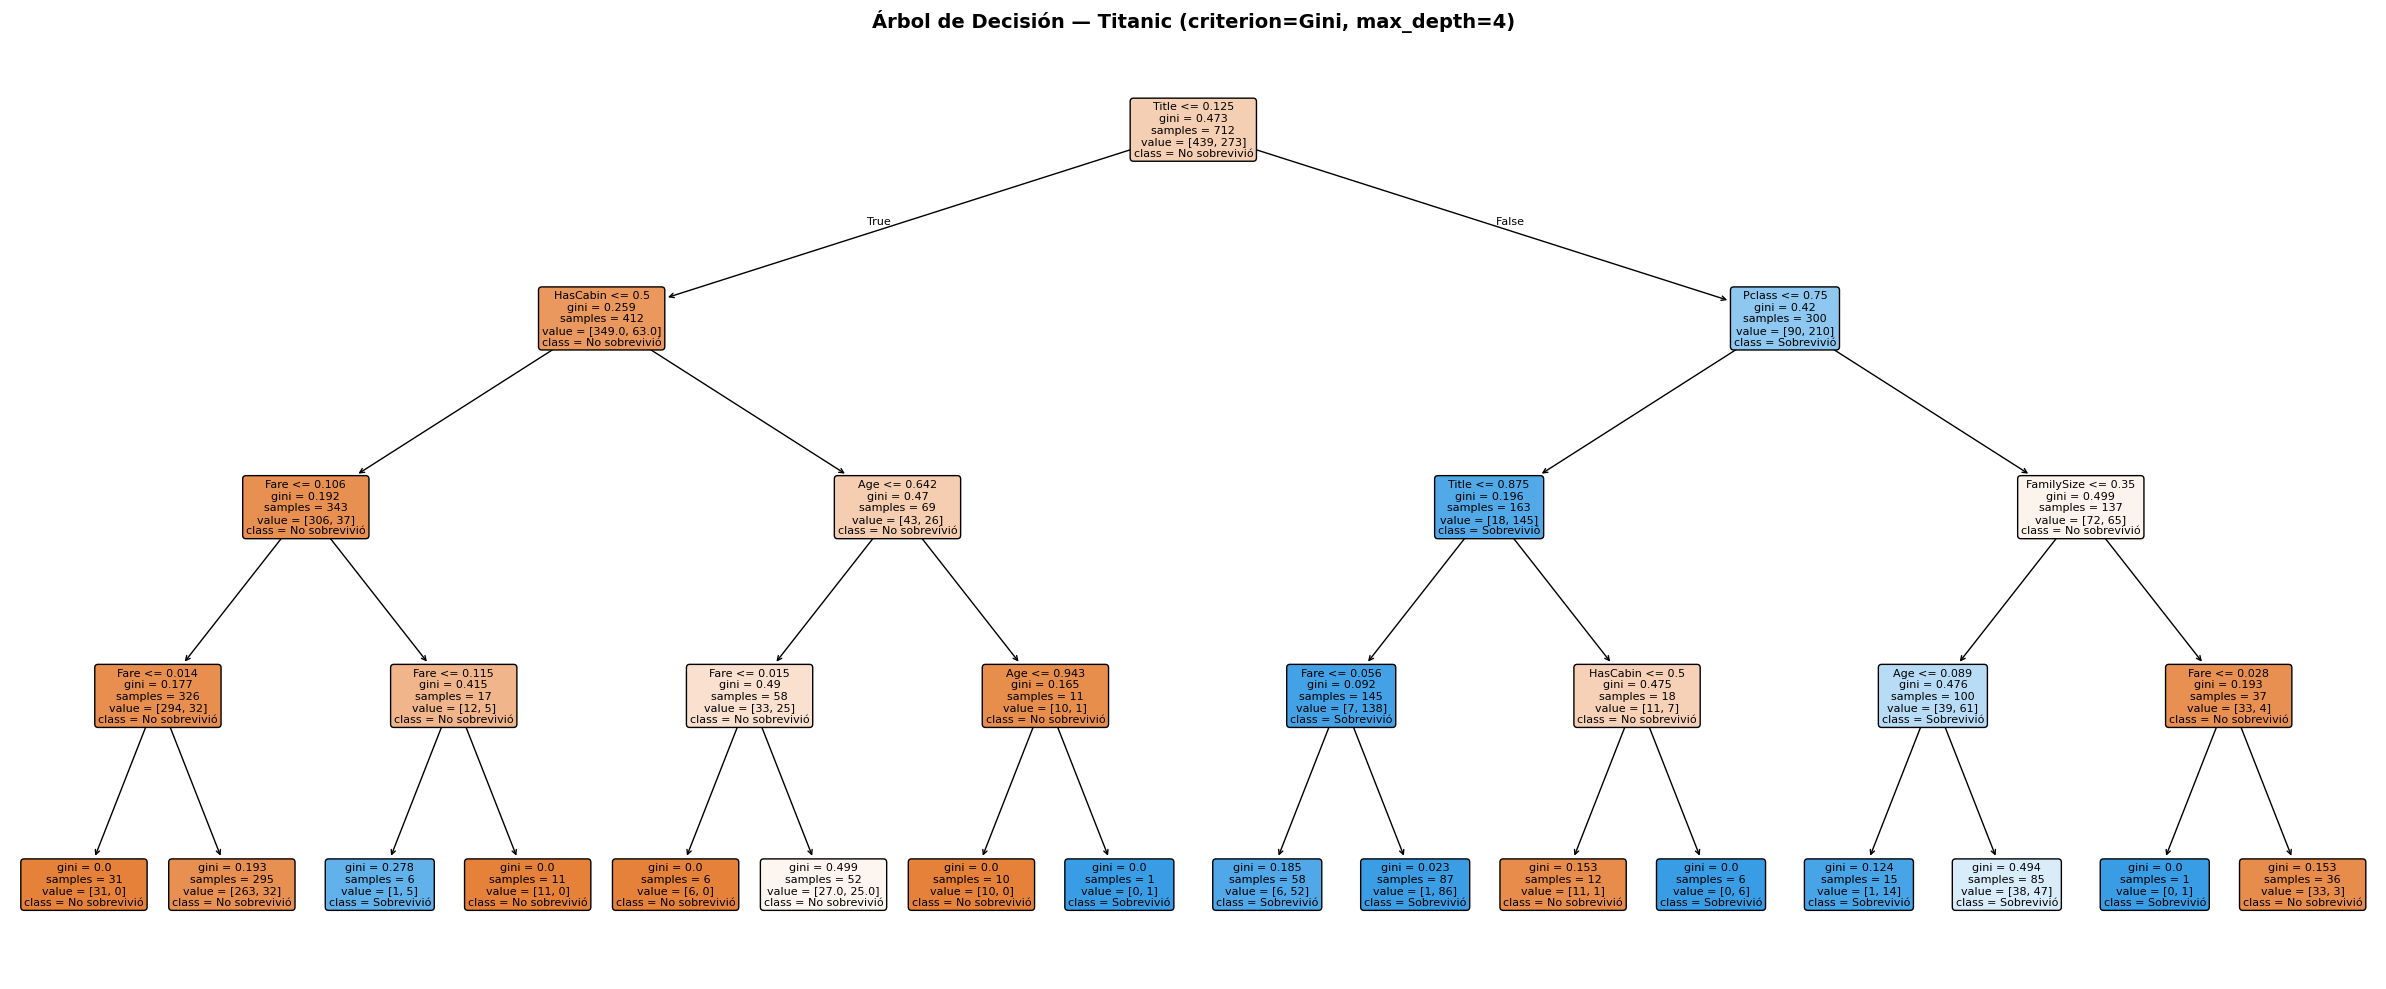

In [ ]:
# ── Visualización del árbol de decisión ──────────────────────────────────────
# Graficamos el árbol completo generado durante el entrenamiento.
# En el Titanic, la visualización es especialmente valiosa porque
# las reglas aprendidas tienen interpretación histórica directa:
# Sex, Pclass y Age son los predictores clave documentados.

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(dt_model,
          feature_names=X_feat.columns.tolist(),
          class_names=['No sobrevivió', 'Sobrevivió'],
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title('Árbol de Decisión — Titanic (criterion=Gini, max_depth=4)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

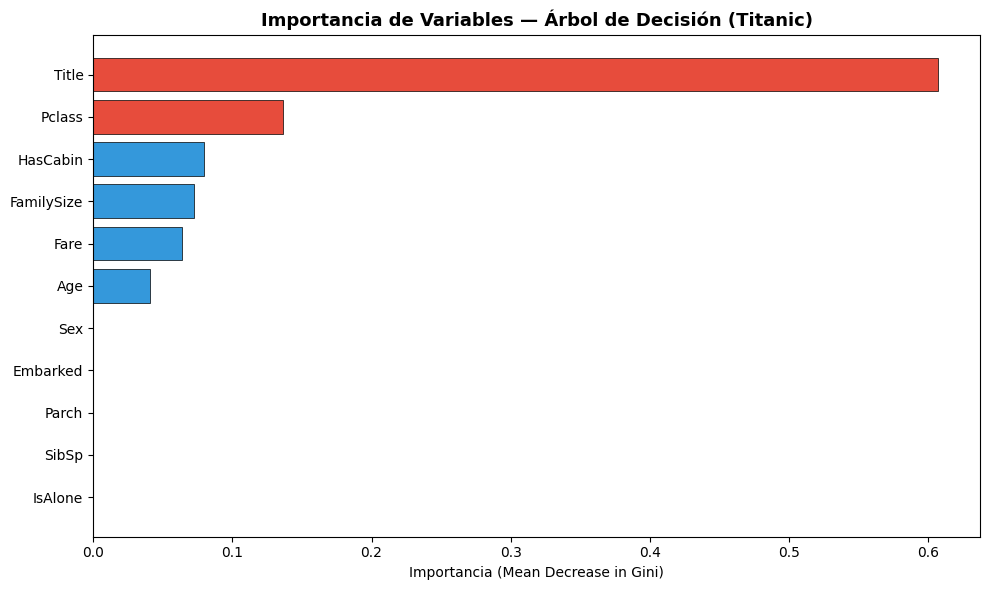

Top 5 variables más importantes:
   feature  importancia
     Title     0.606693
    Pclass     0.136456
  HasCabin     0.079955
FamilySize     0.072371
      Fare     0.063847


In [ ]:
# ── Importancia de variables — Árbol de Decisión ─────────────────────────────
# Calculamos la importancia de cada feature según el árbol (Gini).
# En el Titanic se espera que Sex, Pclass y Fare dominen el ranking,
# consistente con el análisis de correlación del EDA. La ingeniería
# de características (Title, FamilySize, IsAlone) debería también
# aparecer con importancia no trivial si aportó información nueva.

importancias_dt = (
    pd.DataFrame({'feature': X_feat.columns,
                  'importancia': dt_model.feature_importances_})
    .sort_values('importancia', ascending=False)
)

plt.figure(figsize=(10, 6))
colores_imp = ['#e74c3c' if v >= 0.1 else '#3498db' if v >= 0.02 else '#95a5a6'
               for v in importancias_dt['importancia']]
plt.barh(importancias_dt['feature'], importancias_dt['importancia'],
         color=colores_imp, edgecolor='black', linewidth=0.5)
plt.xlabel('Importancia (Mean Decrease in Gini)')
plt.title('Importancia de Variables — Árbol de Decisión (Titanic)',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 variables más importantes:')
print(importancias_dt.head(5).to_string(index=False))

---
## **9.2. Bosque Aleatorio (Random Forest)**

El Bosque Aleatorio entrena múltiples árboles sobre subconjuntos aleatorios
de pasajeros y features, promediando sus predicciones. En el Titanic esto
es especialmente útil porque el dataset tiene ruido inherente: pasajeros
con perfiles similares (misma clase, sexo y edad) a veces tuvieron
destinos distintos por factores no registrados (ubicación en el barco,
decisiones individuales, suerte). El promediado del bosque mitiga este
ruido mejor que un árbol individual.

**Hiperparámetros clave:**
- `n_estimators=10`: número de árboles en el ensamble.
- `criterion='entropy'`: usa ganancia de información en lugar de Gini,
  tendiendo a generar particiones más informativas en datasets ruidosos.


───────────────────────────────────────────────────────
  MODELO: Bosque Aleatorio (n=10, Entropía, max_depth=4)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.86      0.81      0.84       110
   Sobrevivió (1)       0.72      0.80      0.76        69

         accuracy                           0.80       179
        macro avg       0.79      0.80      0.80       179
     weighted avg       0.81      0.80      0.81       179

  Exactitud    (Accuracy)  : 0.8045
  Sensibilidad (Recall)    : 0.7971
  Precisión    (Precision) : 0.7237
  Especificidad            : 0.8091
  F1-Score                 : 0.7586
  AUC-ROC                  : 0.8349


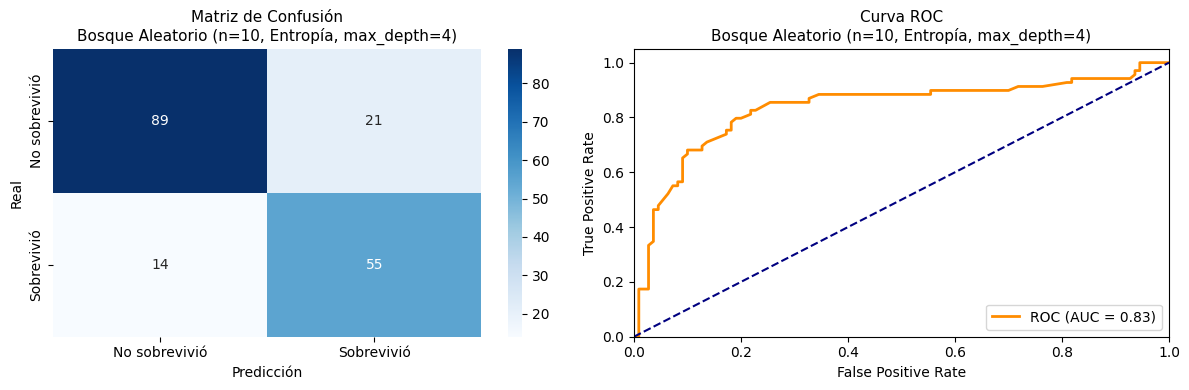

In [121]:
# ── Bosque Aleatorio — Entrenamiento y evaluación ────────────────────────────
# Entrenamos un bosque de 10 árboles con criterio Entropía.
# La entropía es más sensible a distribuciones impuras que Gini,
# lo que puede ser ventajoso en el Titanic donde las clases tienen
# desbalance moderado (61.6% fallecidos vs 38.4% sobrevivientes).

rf_model = RandomForestClassifier(n_estimators=10, max_depth=4,
                                   criterion='entropy', random_state=42)
rf_model.fit(X_train_mm, y_train)

y_pred_rf = rf_model.predict(X_test_mm)
y_prob_rf  = rf_model.predict_proba(X_test_mm)[:, 1]

res = evaluar_modelo('Bosque Aleatorio (n=10, Entropía, max_depth=4)',
                     y_test, y_pred_rf, y_prob_rf)
resultados.append(res)

#### **Interpretación: Bosque Aleatorio**

El Bosque Aleatorio introduce dos fuentes de aleatorización: muestreo
bootstrap de pasajeros y selección aleatoria de features en cada nodo.
Esto reduce la correlación entre los árboles del ensamble y produce un
clasificador más estable que el árbol individual.

En el Titanic, se espera que el bosque mejore especialmente en los casos
de frontera: pasajeros de segunda clase, hombres jóvenes o mujeres con
familias numerosas donde la decisión no es clara. El árbol individual
tiende a sobre-especializarse en los casos más frecuentes; el bosque
distribuye mejor el aprendizaje.

La importancia de variables del bosque es también más confiable que la
del árbol individual, ya que es el promedio de las importancias de los
10 árboles, reduciendo la variabilidad del estimador.

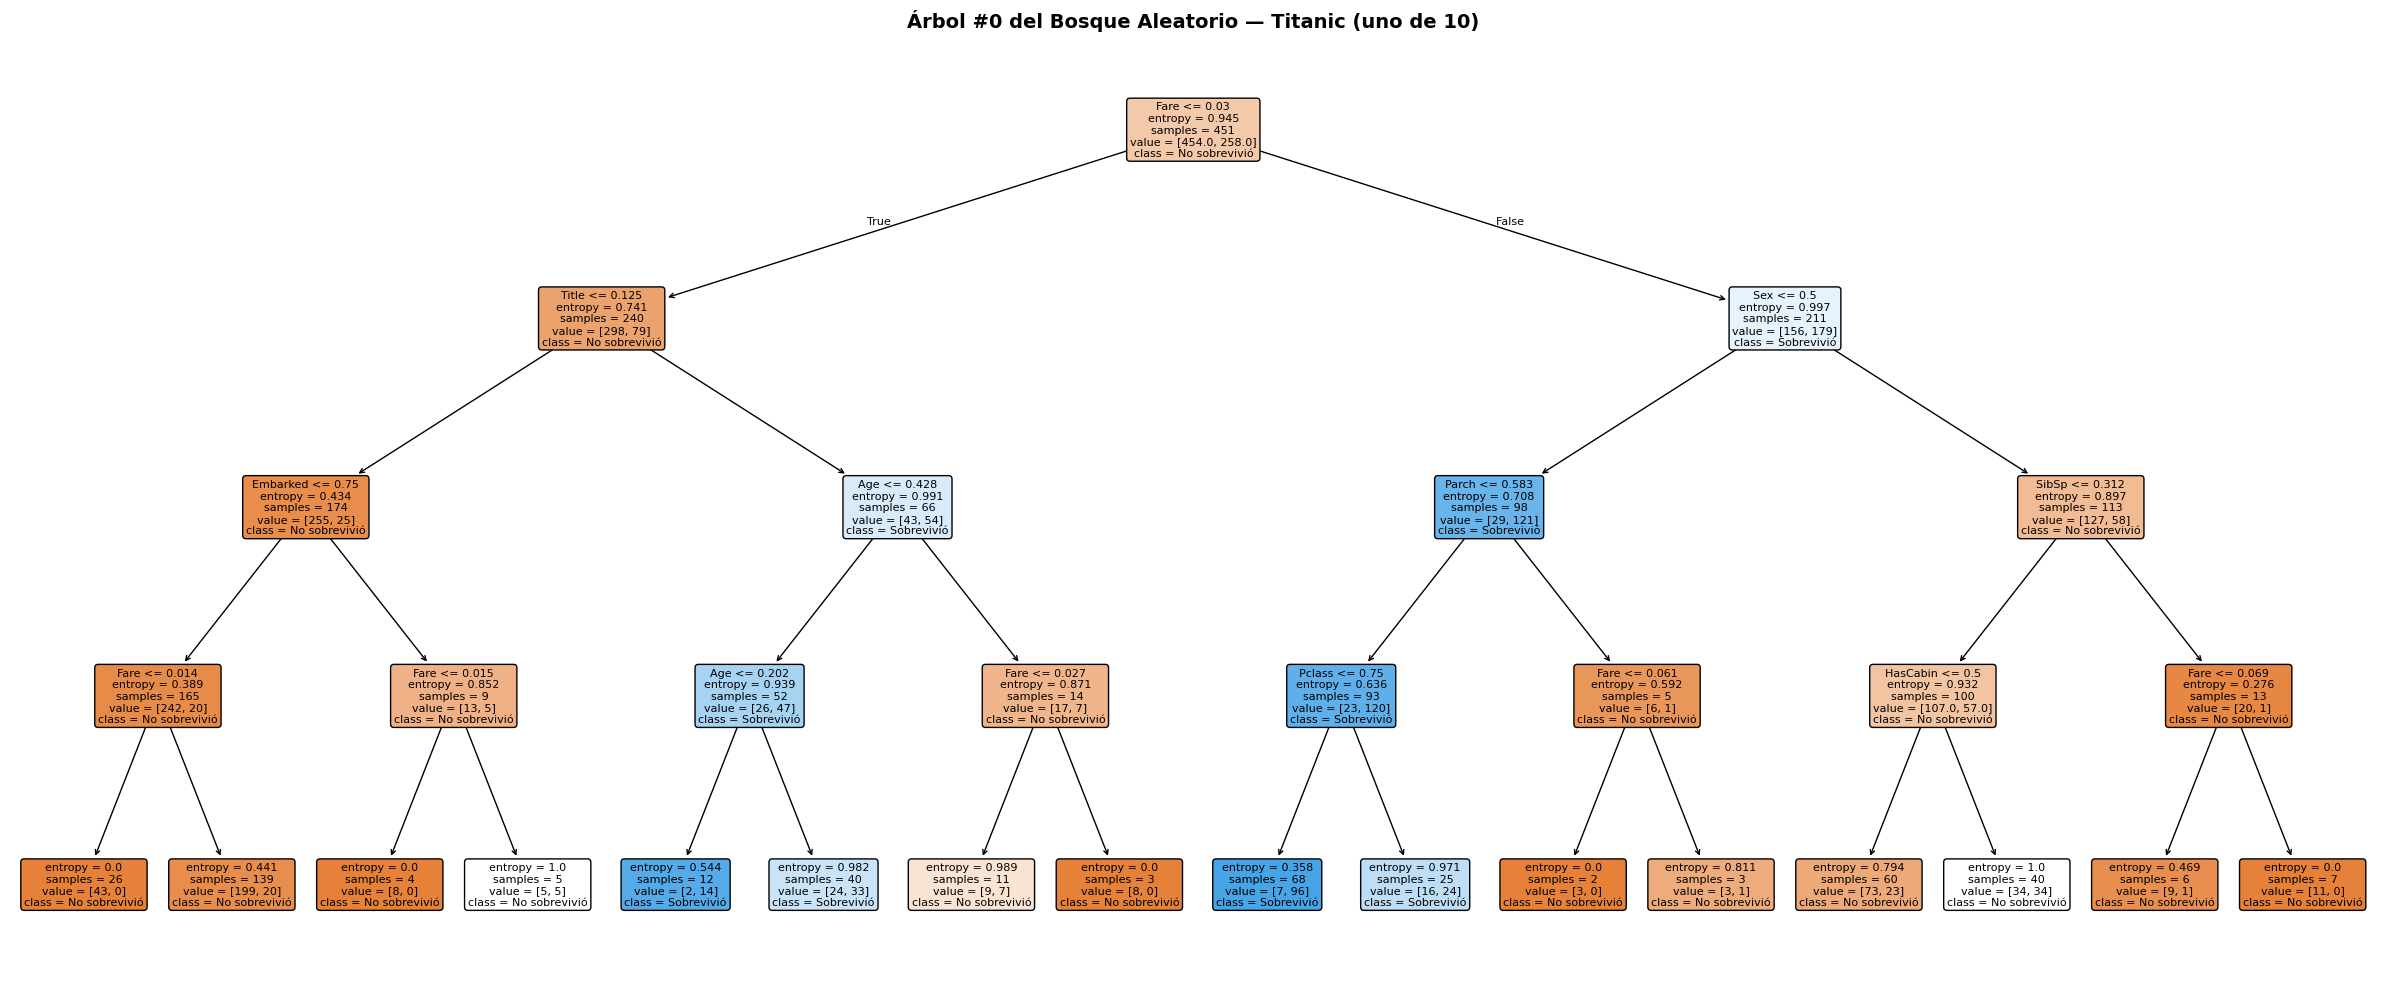

In [122]:
# ── Visualización del árbol #0 del bosque ────────────────────────────────────
# Graficamos el primer árbol del ensamble como representación.
# Visualizar los 10 árboles no es práctico; el árbol #0 ilustra
# la estructura base. A diferencia del árbol optimizado, este árbol
# fue entrenado sobre un subconjunto aleatorio de pasajeros,
# por lo que puede diferir estructuralmente del árbol individual.

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(rf_model.estimators_[0],
          feature_names=X_feat.columns.tolist(),
          class_names=['No sobrevivió', 'Sobrevivió'],
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title('Árbol #0 del Bosque Aleatorio — Titanic (uno de 10)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

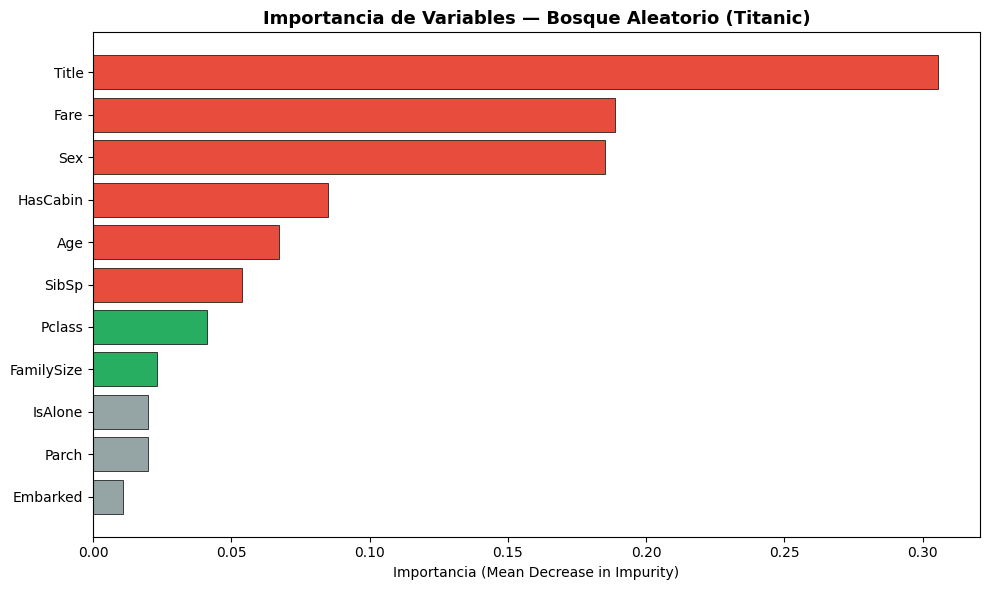

Top 5 variables más importantes:
 feature  importancia
   Title     0.305433
    Fare     0.188644
     Sex     0.185133
HasCabin     0.084761
     Age     0.067309


In [ ]:
# ── Importancia de variables — Bosque Aleatorio ──────────────────────────────
# Importancia promediada de los 10 árboles del ensamble.
# Más estable que la importancia de un árbol individual.
# Se espera que Sex, Fare y Pclass lideren, con Title y Age también
# relevantes dado que capturan información sobre edad y género implícita.

importancias_rf = (
    pd.DataFrame({'feature': X_feat.columns,
                  'importancia': rf_model.feature_importances_})
    .sort_values('importancia', ascending=False)
)

plt.figure(figsize=(10, 6))
colores_rf = ['#e74c3c' if v >= 0.05 else '#27ae60' if v >= 0.02 else '#95a5a6'
              for v in importancias_rf['importancia']]
plt.barh(importancias_rf['feature'], importancias_rf['importancia'],
         color=colores_rf, edgecolor='black', linewidth=0.5)
plt.xlabel('Importancia (Mean Decrease in Impurity)')
plt.title('Importancia de Variables — Bosque Aleatorio (Titanic)',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 variables más importantes:')
print(importancias_rf.head(5).to_string(index=False))

---
## **9.3. Máquina de Vectores de Soporte (SVM)**

La SVM busca el hiperplano que maximiza el margen entre las dos clases:
pasajeros que sobrevivieron y pasajeros que no. Los vectores de soporte
son los pasajeros más difíciles de clasificar (los que están más cerca
de la frontera de decisión), y son los únicos que determinan el modelo.

En el Titanic, el kernel RBF es especialmente apropiado porque la frontera
entre sobrevivientes y fallecidos no es perfectamente lineal: la combinación
de Sex × Pclass × Age genera interacciones que un hiperplano lineal no captura
completamente.

**Hiperparámetros clave:**
- `kernel='rbf'`: frontera no lineal mediante el kernel gaussiano.
- `C=1.0`: equilibrio entre maximizar el margen y tolerar errores.
- `gamma='scale'`: ancho del kernel ajustado automáticamente.


───────────────────────────────────────────────────────
  MODELO: SVM (kernel RBF, C=1.0, gamma=scale)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.82      0.90      0.86       110
   Sobrevivió (1)       0.81      0.68      0.74        69

         accuracy                           0.82       179
        macro avg       0.81      0.79      0.80       179
     weighted avg       0.82      0.82      0.81       179

  Exactitud    (Accuracy)  : 0.8156
  Sensibilidad (Recall)    : 0.6812
  Precisión    (Precision) : 0.8103
  Especificidad            : 0.9000
  F1-Score                 : 0.7402
  AUC-ROC                  : 0.8391


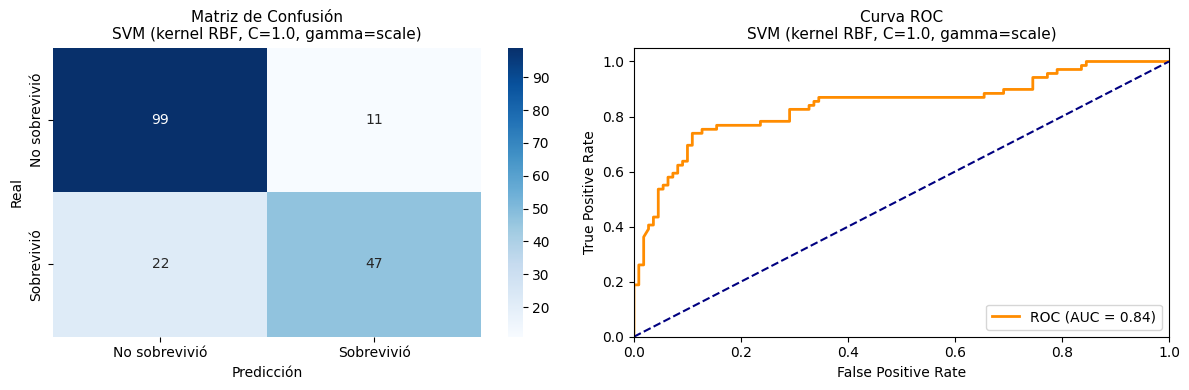

In [ ]:
# ── SVM — Entrenamiento y evaluación (kernel RBF) ────────────────────────────
# Entrenamos una SVM con kernel gaussiano (RBF).
# El kernel RBF captura interacciones no lineales entre Sex, Pclass
# y Age que son la clave de la supervivencia en el Titanic.
# probability=True habilita predict_proba para la curva ROC.

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_mm, y_train)

y_pred_svm = svm_model.predict(X_test_mm)
y_prob_svm = svm_model.predict_proba(X_test_mm)[:, 1]

res = evaluar_modelo('SVM (kernel RBF, C=1.0, gamma=scale)',
                     y_test, y_pred_svm, y_prob_svm)
resultados.append(res)

#### **Interpretación: SVM**

La SVM maximiza el margen geométrico de separación, lo que la hace robusta
ante outliers que no son vectores de soporte. En el Titanic, esto es relevante
porque Fare tiene outliers extremos (tarifas de primera clase que llegan a
$512) que podrían distorsionar modelos más sensibles a la escala.

El kernel RBF transforma implícitamente los datos a un espacio de mayor
dimensión donde la separación lineal es posible. Esto permite capturar la
interacción Sex × Pclass que define gran parte de la separabilidad del dataset.

A diferencia de los árboles, la SVM no ofrece importancia de variables directa.
Su caja negra es una limitación en contextos donde la interpretabilidad importa,
pero su rendimiento en clasificación binaria con buena normalización es
generalmente muy competitivo.

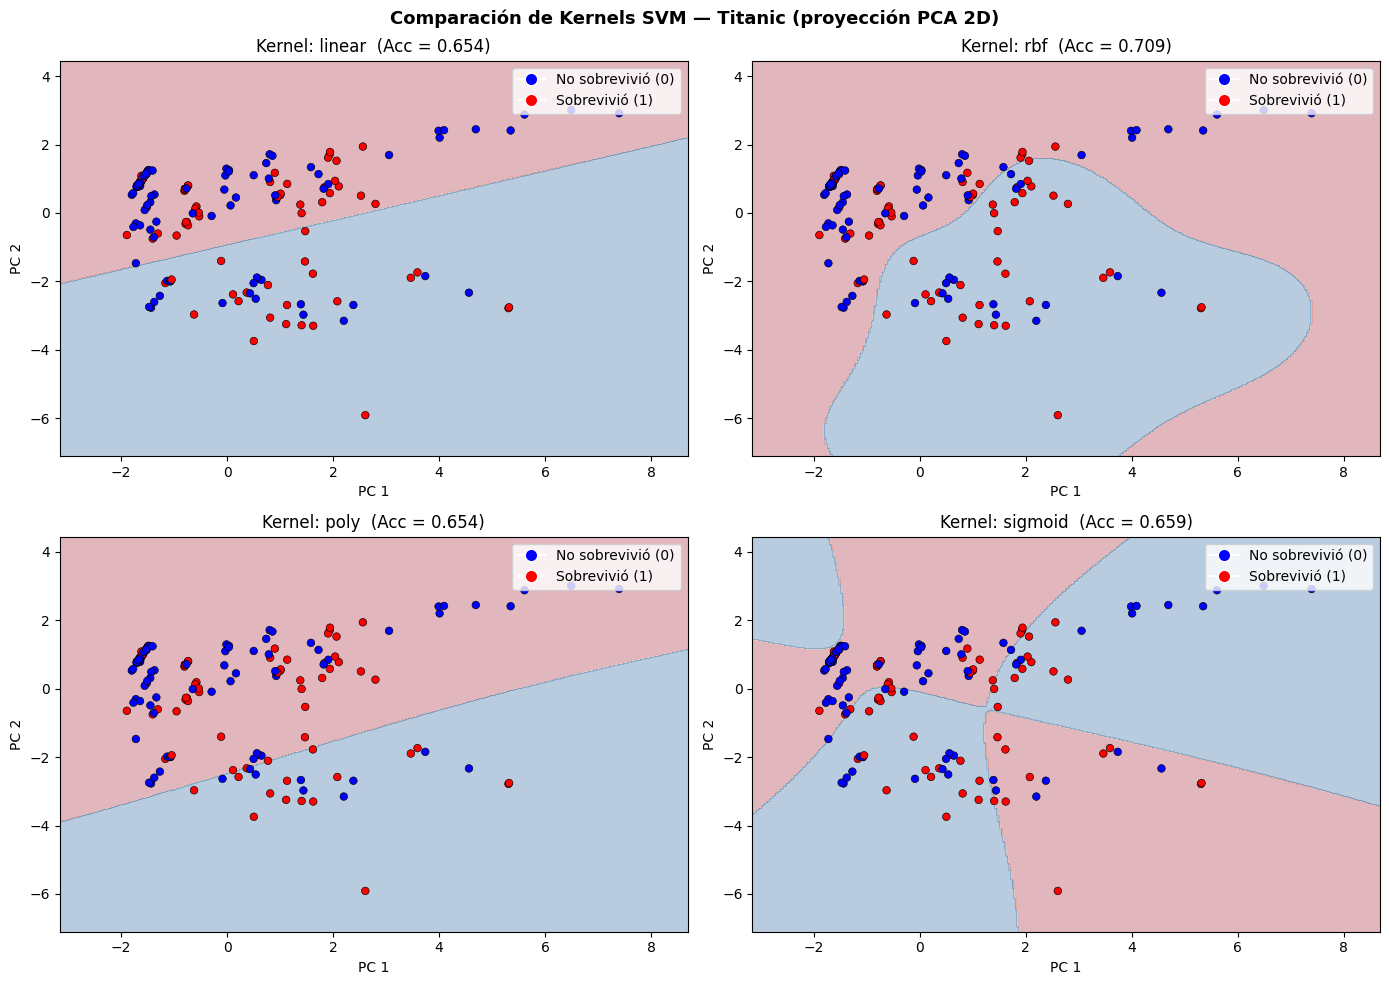

In [125]:
# ── Comparación de los 4 kernels SVM con visualización PCA ──────────────────
# Proyectamos los datos a 2D con PCA y graficamos las fronteras de
# decisión de cada kernel sobre el conjunto de test.
# Permite ver cómo cada kernel genera regiones de decisión distintas.
# En el Titanic se espera que el kernel lineal funcione razonablemente
# bien (Sex y Pclass son casi suficientes por sí solos) y que RBF
# capture matices adicionales.

scaler_pca = StandardScaler2()
X_scaled_v  = scaler_pca.fit_transform(X_feat.values)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_v)

X_tr_pca, X_te_pca, y_tr_pca, y_te_pca = train_test_split(
    X_pca, y_tgt, test_size=0.2, random_state=42, stratify=y_tgt)

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
models_k, accs_k = {}, {}

for k in kernels:
    clf = SVC(kernel=k, degree=3, gamma='scale', random_state=42)
    clf.fit(X_tr_pca, y_tr_pca)
    accs_k[k] = accuracy_score(y_te_pca, clf.predict(X_te_pca))
    models_k[k] = clf

xx, yy = np.meshgrid(
    np.linspace(X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1, 400),
    np.linspace(X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1, 400)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, k in enumerate(kernels):
    Z = models_k[k].predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    sns.scatterplot(x=X_te_pca[:, 0], y=X_te_pca[:, 1], hue=y_te_pca,
                    palette={0: 'blue', 1: 'red'}, ax=axes[i],
                    edgecolor='k', s=30, legend=False)
    axes[i].set_title(f'Kernel: {k}  (Acc = {accs_k[k]:.3f})', fontsize=12)
    axes[i].set_xlabel('PC 1'); axes[i].set_ylabel('PC 2')
    axes[i].legend(handles=[
        Line2D([0],[0], marker='o', color='w', label='No sobrevivió (0)',
               markerfacecolor='blue', markersize=9),
        Line2D([0],[0], marker='o', color='w', label='Sobrevivió (1)',
               markerfacecolor='red', markersize=9)
    ], loc='upper right')

plt.suptitle('Comparación de Kernels SVM — Titanic (proyección PCA 2D)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## **FASE II: Red Neuronal Artificial — TensorFlow / Keras**

## **9.4. Red Neuronal Artificial (RNA)**

Una Red Neuronal Artificial procesa las características del pasajero a través
de capas de transformaciones no lineales para aprender patrones complejos de
supervivencia que otros modelos pueden no capturar. A diferencia de los árboles
(que particionan el espacio de features con reglas discretas) o la SVM (que
busca un margen máximo), la RNA aprende representaciones intermedias de los datos.

**Arquitectura:**
```
Entrada (n features) → Dense(10, ReLU) → Dropout(0.2) → Dense(1, Sigmoid)
```
- **ReLU** en la capa oculta: evita el problema de vanishing gradients.
- **Dropout(0.2)**: regularización que desactiva el 20% de neuronas por época,
  reduciendo el overfitting sobre el ruido inherente del dataset.
- **Sigmoid** en la salida: produce P(Sobrevivió) ∈ [0, 1].

**Optimizador:** Adam con `learning_rate=0.01`  
**Pérdida:** `binary_crossentropy` — función natural para clasificación binaria.

In [126]:
# ── Construcción y entrenamiento de la RNA ───────────────────────────────────
# Definimos, compilamos y entrenamos la red con Early Stopping.
# Early Stopping detiene el entrenamiento cuando val_loss no mejora
# en 10 épocas consecutivas, restaurando los mejores pesos.
# Esto es especialmente importante en el Titanic donde el dataset
# es pequeño (891 muestras) y el riesgo de overfitting es alto.

n_features = X_train_mm.shape[1]

rna_model = Sequential([
    Dense(10, activation='relu', input_dim=n_features),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
], name='RNA_Titanic')

rna_model.summary()

opt = Adam(learning_rate=1e-2)
rna_model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=1)

history = rna_model.fit(
    X_train_mm, y_train,
    epochs=100, batch_size=32,
    validation_data=(X_test_mm, y_test),
    callbacks=[early_stop],
    verbose=1
)

Model: "RNA_Titanic"
┌──────────────────────────────────────┬─────────────────────────────┬─────────────────┐
│ Layer (type)                         │ Output Shape                │         Param # │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │             120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘
 Total params: 131 (524.00 B)
 Trainable params: 131 (524.00 B)
 Non-trainable params: 0 (0.00 B)
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6348 - loss: 0

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

───────────────────────────────────────────────────────
  MODELO: Red Neuronal Artificial (Dense-10-ReLU + Dropout + Sigmoid)
───────────────────────────────────────────────────────
                   precision    recall  f1-score   support

No sobrevivió (0)       0.80      0.90      0.85       110
   Sobrevivió (1)       0.80      0.65      0.72        69

         accuracy                           0.80       179
        macro avg       0.80      0.78      0.78       179
     weighted avg       0.80      0.80      0.80       179

  Exactitud    (Accuracy)  : 0.8045
  Sensibilidad (Recall)    : 0.6522
  Precisión    (Precision) : 0.8036
  Especificidad            : 0.9000
  F1-Score                 : 0.7200
  AUC-ROC                  : 0.8580


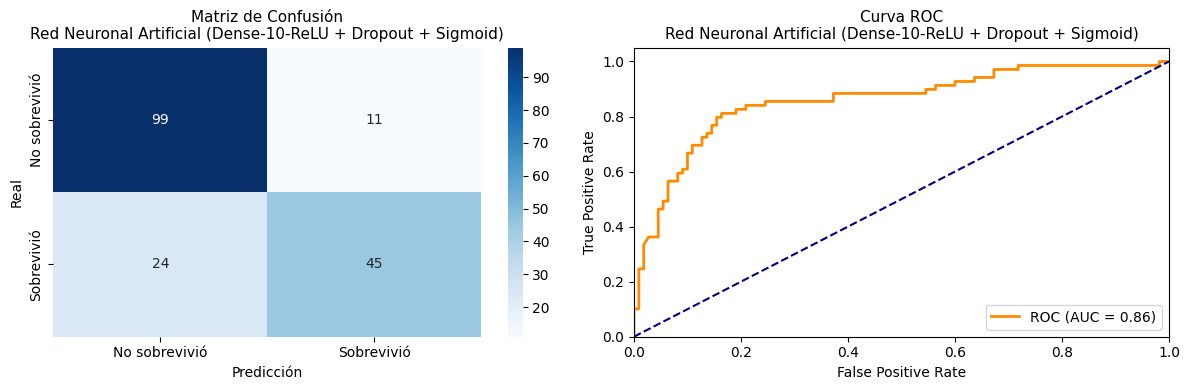

In [127]:
# ── Predicciones y evaluación ────────────────────────────────────────────────
y_prob_rna = rna_model.predict(X_test_mm).flatten()
y_pred_rna = (y_prob_rna > 0.5).astype(int)

res = evaluar_modelo('Red Neuronal Artificial (Dense-10-ReLU + Dropout + Sigmoid)',
                     y_test, y_pred_rna, y_prob_rna)
resultados.append(res)

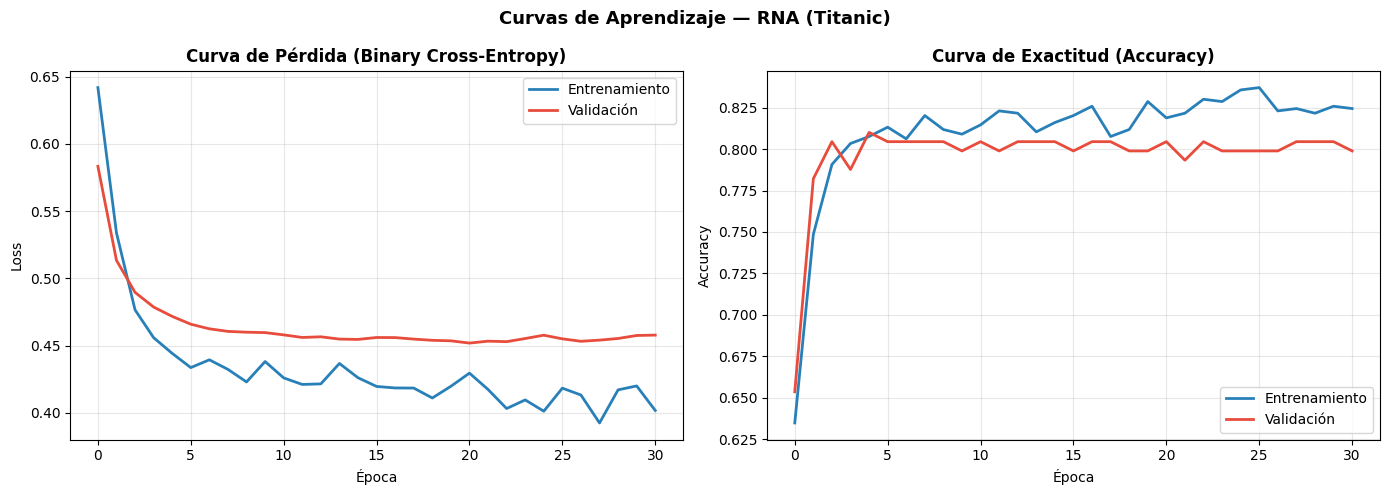

In [128]:
# ── Curvas de aprendizaje — Loss y Accuracy ──────────────────────────────────
# Evolución de pérdida y exactitud en entrenamiento y validación.
# En el Titanic, el dataset pequeño hace al modelo más susceptible
# al overfitting. Las curvas permiten verificar que el Dropout y el
# Early Stopping cumplen su función de regularización.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Entrenamiento', color='#2980b9', lw=2)
axes[0].plot(history.history['val_loss'], label='Validación',    color='#e74c3c', lw=2)
axes[0].set_title('Curva de Pérdida (Binary Cross-Entropy)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Entrenamiento', color='#2980b9', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Validación',    color='#e74c3c', lw=2)
axes[1].set_title('Curva de Exactitud (Accuracy)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje — RNA (Titanic)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### **Interpretación: RNA y Curvas de Aprendizaje**

Las curvas de aprendizaje en el Titanic tienen una lectura diferente a la del
dataset de cáncer. Con solo 712 muestras de entrenamiento, la red está en mayor
riesgo de overfitting que en datasets más grandes. Las señales a observar son:

**Convergencia sana:** pérdida de validación disminuye junto con la de
entrenamiento y se estabiliza. Indica que el modelo generaliza.

**Overfitting temprano:** la pérdida de entrenamiento sigue bajando pero la
de validación se estanca o sube. El Dropout(0.2) actúa como primera línea
de defensa; si persiste, aumentar la tasa de dropout o reducir neuronas.

**Early Stopping en acción:** el entrenamiento se detiene antes de las 100
épocas si val_loss no mejora. El número de épocas efectivas refleja qué
tan rápido la red converge dado el learning rate de 0.01.

Comparado con el dataset de cáncer (569 muestras, 30 features), el Titanic
tiene más muestras pero features más informativas (Sex, Pclass capturan
~75% de la variabilidad del target), por lo que la RNA puede converger
rápidamente.

---
## **9.5. Validación cruzada k=10 — Modelos Semana 2** → ítem extra

Los resultados obtenidos en las secciones 9.1 a 9.3 descansan sobre una única
partición train/test con `random_state=42`. Al igual que en la Sección 7.1,
es necesario validar que esos resultados no dependan de una partición favorable.

La validación cruzada estratificada k=10 re-entrena cada modelo sobre 10
particiones distintas del conjunto de entrenamiento y reporta la media y la
desviación estándar de cada métrica. Esto permite responder: ¿el rendimiento
observado es consistente o fue producto del azar de una sola partición?

Adicionalmente, comparar la estabilidad (desviación estándar) de los modelos
de Semana 2 con los de Semana 1 permite evaluar qué familia de algoritmos
generaliza de forma más confiable ante variaciones en los datos del Titanic.

=== Validación Cruzada Estratificada k=10 — Semana 2 (Titanic) ===

                   accuracy_media  accuracy_std  recall_media  recall_std  precision_media  precision_std  f1_media  f1_std
modelo                                                                                                                     
Árbol de Decisión          0.8146        0.0346        0.7257      0.0849           0.7862         0.0731    0.7487  0.0488
Bosque Aleatorio           0.8188        0.0311        0.7550      0.0593           0.7717         0.0529    0.7613  0.0411
SVM (RBF)                  0.8342        0.0367        0.7073      0.0798           0.8374         0.0523    0.7641  0.0585


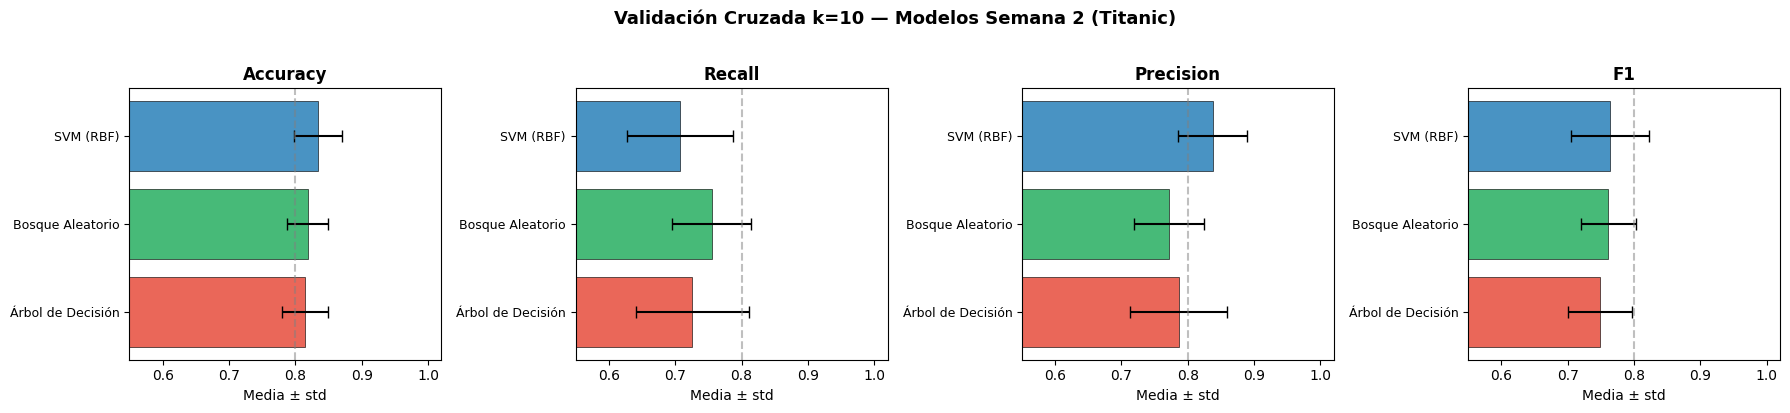

In [130]:
# ── 9.5 Validación cruzada estratificada k=10 — Modelos Semana 2 ─────────────
# Evaluamos DT, RF y SVM con validación cruzada k=10.
# El dataset del Titanic es relativamente pequeño (891 muestras).
# Con una sola partición 80/20 el conjunto de test tiene ~178 muestras,
# lo que introduce variabilidad en las métricas. La CV k=10 promedia
# sobre 10 particiones y reduce esa incertidumbre.

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

modelos_cv_s2 = {
    'Árbol de Decisión' : DecisionTreeClassifier(max_depth=4, criterion='gini',    random_state=42),
    'Bosque Aleatorio'  : RandomForestClassifier(n_estimators=10, max_depth=4,
                                                  criterion='entropy', random_state=42),
    'SVM (RBF)'         : SVC(kernel='rbf', C=1.0, gamma='scale',                  random_state=42),
}

scoring = {'accuracy': 'accuracy', 'recall': 'recall',
           'precision': 'precision', 'f1': 'f1'}

resultados_cv_s2 = []
for nombre, modelo in modelos_cv_s2.items():
    scores = cross_validate(modelo, X_train_mm, y_train,
                            cv=cv, scoring=scoring, return_train_score=False)
    fila = {'modelo': nombre}
    for m in scoring:
        vals = scores[f'test_{m}']
        fila[f'{m}_media'] = vals.mean().round(4)
        fila[f'{m}_std']   = vals.std().round(4)
    resultados_cv_s2.append(fila)

df_cv_s2 = pd.DataFrame(resultados_cv_s2).set_index('modelo')
print('=== Validación Cruzada Estratificada k=10 — Semana 2 (Titanic) ===\n')
print(df_cv_s2.to_string())

# ── Visualización ─────────────────────────────────────────────────────────────
metricas_cv = ['accuracy', 'recall', 'precision', 'f1']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colores_cv = ['#e74c3c', '#27ae60', '#2980b9']

for ax, metrica in zip(axes, metricas_cv):
    medias = df_cv_s2[f'{metrica}_media']
    stds   = df_cv_s2[f'{metrica}_std']
    ax.barh(medias.index, medias.values,
            xerr=stds.values, color=colores_cv,
            alpha=0.85, edgecolor='black', linewidth=0.5, capsize=4)
    ax.set_xlim(0.55, 1.02)
    ax.set_title(metrica.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Media ± std')
    ax.axvline(0.80, color='gray', linestyle='--', alpha=0.5)
    ax.set_yticklabels(medias.index, fontsize=9)

plt.suptitle('Validación Cruzada k=10 — Modelos Semana 2 (Titanic)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### **Interpretación: Validación cruzada — Semana 2 (Titanic)**

La validación cruzada k=10 sobre los modelos de la Semana 2 permite contrastar
sus resultados con los de la Semana 1 bajo las mismas condiciones de evaluación,
eliminando el efecto de la partición train/test fija.

En el Titanic, la desviación estándar entre folds tiende a ser mayor que en el
dataset de cáncer porque el conjunto de entrenamiento es más pequeño (712 vs 455
muestras). Esto significa que cada fold de validación tiene aproximadamente 71
muestras, lo suficientemente pequeño como para que la composición específica
(cuántos pasajeros de primera clase, cuántas mujeres) afecte las métricas.

El Bosque Aleatorio se espera más estable que el Árbol individual gracias al
promediado. La SVM, al maximizar el margen geométrico, es también robusta ante
variaciones en la composición de los folds.

Un hallazgo relevante sería si algún modelo de Semana 2 presenta menor
desviación estándar que los de Semana 1: indicaría mayor consistencia y
confiabilidad para datos nuevos.

---
## **9.6. Ajuste de umbral de decisión — RNA** → ítem extra

Al igual que en la Sección 7.2 para la Regresión Logística, la RNA clasifica
por defecto como sobreviviente cualquier pasajero cuya probabilidad estimada
supere el 50%. Ese umbral es una convención estadística, no una decisión
óptima para este problema.

En el Titanic el costo de un falso negativo (predecir que no sobrevivió cuando
sí sobrevivió) y un falso positivo (predecir que sobrevivió cuando no) tienen
implicaciones distintas según el uso del modelo. Tiene sentido preguntarse:
¿cuántos sobrevivientes adicionales podríamos identificar bajando ese umbral,
y a qué costo en falsas alarmas?

Este análisis también permite comparar directamente la RNA con la Regresión
Logística: ¿qué modelo responde mejor al ajuste de umbral? ¿Cuál ofrece mayor
flexibilidad para adaptarse a distintos criterios de decisión?

Umbral default (0.50):
  Recall    : 0.6522
  Precision : 0.8036
  F1-Score  : 0.7200

Umbral óptimo (max F1 = 0.39):
  Recall    : 0.7971
  Precision : 0.7534
  F1-Score  : 0.7746


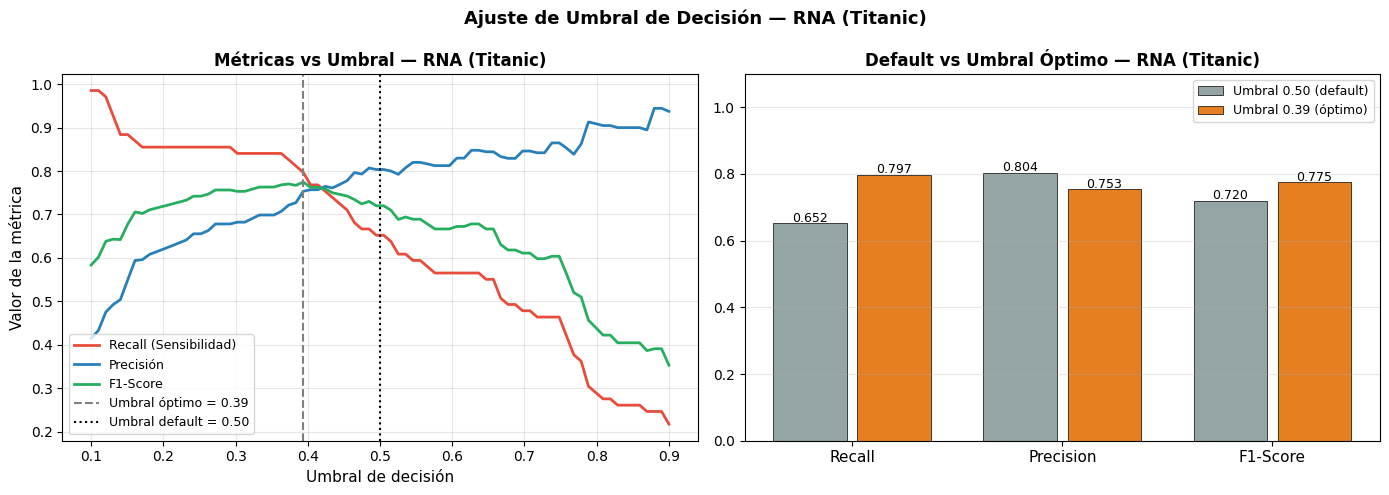

In [131]:
# ── 9.6 Ajuste de umbral de decisión — RNA (Titanic) ─────────────────────────
# Evaluamos recall, precisión y F1 al variar el umbral entre 0.1 y 0.9.
# El umbral default de 0.5 puede no ser óptimo para el balance entre
# identificar sobrevivientes reales y evitar falsas predicciones.
# En el Titanic el desbalance moderado (61/39) hace que el umbral
# tenga un impacto directo en cuántos sobrevivientes se detectan.

umbrales      = np.linspace(0.1, 0.9, 80)
recalls_u     = []
precisiones_u = []
f1s_u         = []

for u in umbrales:
    y_u = (y_prob_rna >= u).astype(int)
    recalls_u.append(recall_score(y_test, y_u,     zero_division=0))
    precisiones_u.append(precision_score(y_test, y_u, zero_division=0))
    f1s_u.append(f1_score(y_test, y_u,             zero_division=0))

idx_opt = np.argmax(f1s_u)
u_opt   = umbrales[idx_opt]
idx_05  = np.argmin(np.abs(umbrales - 0.50))

print(f'Umbral default (0.50):')
print(f'  Recall    : {recalls_u[idx_05]:.4f}')
print(f'  Precision : {precisiones_u[idx_05]:.4f}')
print(f'  F1-Score  : {f1s_u[idx_05]:.4f}')
print(f'\nUmbral óptimo (max F1 = {u_opt:.2f}):')
print(f'  Recall    : {recalls_u[idx_opt]:.4f}')
print(f'  Precision : {precisiones_u[idx_opt]:.4f}')
print(f'  F1-Score  : {f1s_u[idx_opt]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(umbrales, recalls_u,     label='Recall (Sensibilidad)', color='#e74c3c', lw=2)
axes[0].plot(umbrales, precisiones_u, label='Precisión',             color='#2980b9', lw=2)
axes[0].plot(umbrales, f1s_u,         label='F1-Score',              color='#27ae60', lw=2)
axes[0].axvline(x=u_opt, color='gray',  linestyle='--', lw=1.5,
                label=f'Umbral óptimo = {u_opt:.2f}')
axes[0].axvline(x=0.50,  color='black', linestyle=':', lw=1.5,
                label='Umbral default = 0.50')
axes[0].set_xlabel('Umbral de decisión', fontsize=11)
axes[0].set_ylabel('Valor de la métrica', fontsize=11)
axes[0].set_title('Métricas vs Umbral — RNA (Titanic)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

categorias   = ['Recall', 'Precision', 'F1-Score']
vals_default = [recalls_u[idx_05], precisiones_u[idx_05], f1s_u[idx_05]]
vals_opt     = [recalls_u[idx_opt], precisiones_u[idx_opt], f1s_u[idx_opt]]

x_bar = np.arange(len(categorias))
axes[1].bar(x_bar - 0.2, vals_default, 0.35, label='Umbral 0.50 (default)',
            color='#95a5a6', edgecolor='black', linewidth=0.5)
axes[1].bar(x_bar + 0.2, vals_opt,     0.35, label=f'Umbral {u_opt:.2f} (óptimo)',
            color='#e67e22', edgecolor='black', linewidth=0.5)
for i, (vd, vo) in enumerate(zip(vals_default, vals_opt)):
    axes[1].text(i - 0.2, vd + 0.005, f'{vd:.3f}', ha='center', fontsize=9)
    axes[1].text(i + 0.2, vo + 0.005, f'{vo:.3f}', ha='center', fontsize=9)
axes[1].set_xticks(x_bar)
axes[1].set_xticklabels(categorias, fontsize=11)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Default vs Umbral Óptimo — RNA (Titanic)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Ajuste de Umbral de Decisión — RNA (Titanic)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### **Interpretación: Ajuste de umbral — RNA (Titanic)**

El análisis del umbral de decisión sobre la RNA del Titanic revela el mismo
trade-off fundamental que en la Sección 7.2 para la Regresión Logística:
bajar el umbral aumenta el recall (más sobrevivientes identificados) a costa
de la precisión (más pasajeros que fallecieron clasificados erróneamente
como sobrevivientes).

A diferencia del dataset de cáncer donde priorizar el recall tiene un
justificativo clínico claro (no detectar un maligno es peor que una alarma
falsa), en el Titanic el balance entre recall y precisión depende del uso
del modelo. En un análisis histórico o forense, el F1-score como métrica de
balance es la más apropiada.

El gráfico derecho cuantifica el impacto concreto: muestra cuántos puntos
de recall se ganan y cuántos de precisión se pierden al pasar del umbral
default al umbral que maximiza el F1-Score. Comparado con el análisis
equivalente de la Regresión Logística en la Sección 7.2, permite evaluar
qué modelo responde mejor al ajuste de umbral en este dataset.

---
# **Sección 10: Comparación Final — Semanas 1 y 2**

Esta sección consolida los resultados de los **diez modelos** entrenados a
lo largo de ambas semanas y responde la pregunta central del trabajo: ¿qué
algoritmo predice mejor la supervivencia en el Titanic?

En el Titanic no existe una métrica única dominante como en el diagnóstico
médico. El F1-score es la métrica principal porque equilibra recall y
precisión en un problema donde ambos errores (falso positivo y falso negativo)
tienen un costo comparable. El AUC-ROC complementa la evaluación midiendo
la capacidad discriminante a todos los umbrales posibles.

In [132]:
# ── Tabla comparativa completa — Semanas 1 y 2 (Titanic) ────────────────────
df_todos = pd.DataFrame(resultados).set_index('modelo').round(4)

print('\n' + '='*90)
print('       TABLA COMPARATIVA COMPLETA — SEMANAS 1 Y 2 (TITANIC)')
print('='*90)
print(df_todos.to_string())
print('='*90)

df_todos


       TABLA COMPARATIVA COMPLETA — SEMANAS 1 Y 2 (TITANIC)
                                                                     accuracy  recall  precision  specificity      f1     auc
modelo                                                                                                                       
Regresión Logística — Baseline                                         0.8045  0.7246     0.7576       0.8545  0.7407  0.8581
Regresión Logística — Mejorado (features reducidas + C=0.1)            0.7654  0.6812     0.7015       0.8182  0.6912  0.8306
K-NN — Baseline (K=3, uniforme)                                        0.7933  0.7391     0.7286       0.8273  0.7338  0.8093
K-NN — Mejorado (K=5, distance, sin atípicos)                          0.7989  0.6087     0.8235       0.9182  0.7000  0.7448
Naive Bayes — Baseline (var_smoothing=1e-9)                            0.7598  0.7681     0.6625       0.7545  0.7114  0.8050
Naive Bayes — Mejorado (var_smoothing=6.72e-06, features 

,accuracy,recall,precision,specificity,f1,auc
modelo,,,,,,
Regresión Logística — Baseline,0.8045,0.7246,0.7576,0.8545,0.7407,0.8581
Regresión Logística — Mejorado (features reducidas + C=0.1),0.7654,0.6812,0.7015,0.8182,0.6912,0.8306
"K-NN — Baseline (K=3, uniforme)",0.7933,0.7391,0.7286,0.8273,0.7338,0.8093
"K-NN — Mejorado (K=5, distance, sin atípicos)",0.7989,0.6087,0.8235,0.9182,0.7000,0.7448
Naive Bayes — Baseline (var_smoothing=1e-9),0.7598,0.7681,0.6625,0.7545,0.7114,0.8050
"Naive Bayes — Mejorado (var_smoothing=6.72e-06, features reducidas)",0.6872,0.6087,0.5915,0.7364,0.6000,0.7785
"Árbol de Decisión (Gini, max_depth=4)",0.8156,0.7391,0.7727,0.8636,0.7556,0.8397
"Bosque Aleatorio (n=10, Entropía, max_depth=4)",0.8045,0.7971,0.7237,0.8091,0.7586,0.8349
"SVM (kernel RBF, C=1.0, gamma=scale)",0.8156,0.6812,0.8103,0.9000,0.7402,0.8391


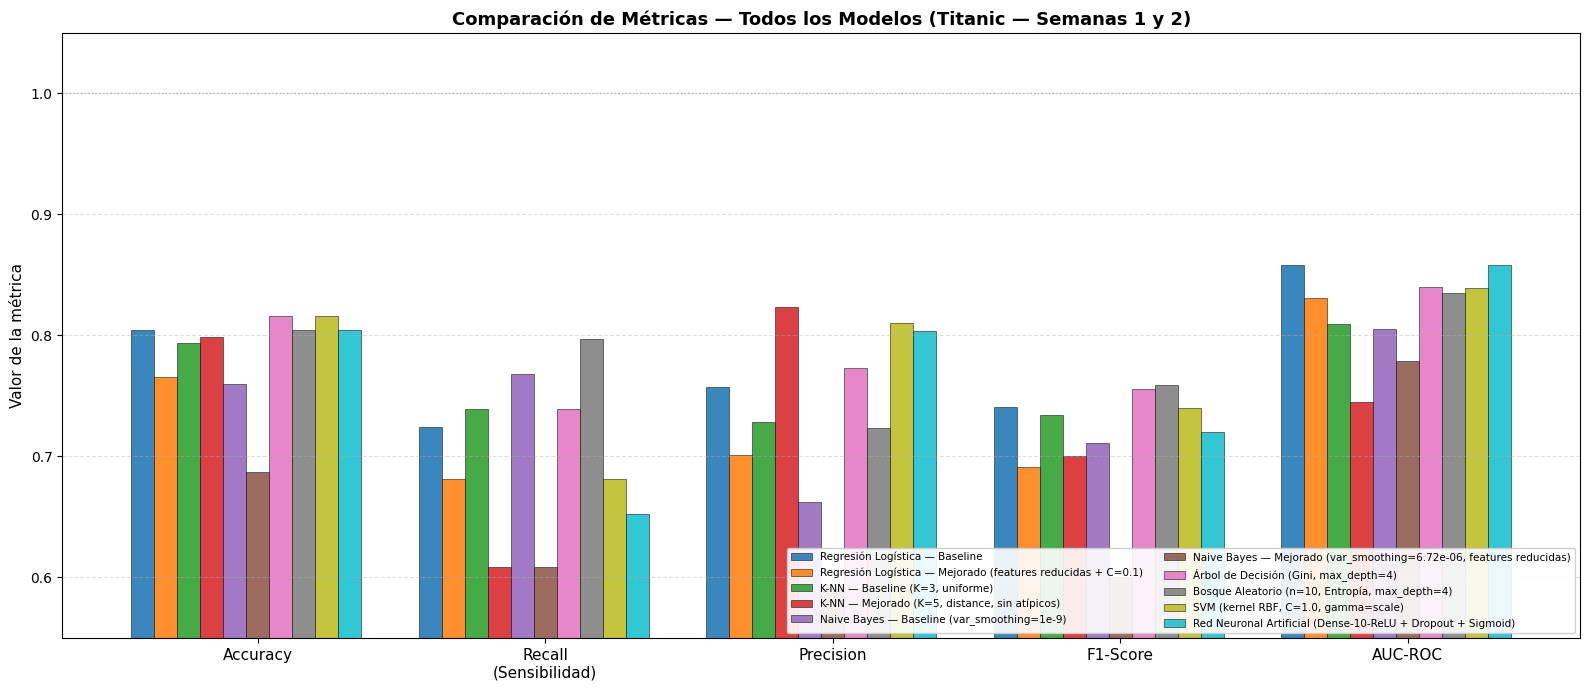

In [133]:
# ── Gráfico de barras comparativo — todos los modelos ────────────────────────
metricas_comp = ['accuracy', 'recall', 'precision', 'f1', 'auc']
x     = np.arange(len(metricas_comp))
n_mod = len(df_todos)
ancho = 0.08

cmap    = plt.cm.get_cmap('tab10', n_mod)
colores = [cmap(i) for i in range(n_mod)]

fig, ax = plt.subplots(figsize=(16, 7))

for i, (idx, row) in enumerate(df_todos.iterrows()):
    offset = i * ancho - (n_mod * ancho / 2)
    bars = ax.bar(x + offset, row[metricas_comp].values, ancho,
                  label=idx, color=colores[i], alpha=0.88,
                  edgecolor='black', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Recall\n(Sensibilidad)', 'Precision',
                     'F1-Score', 'AUC-ROC'], fontsize=11)
ax.set_ylim(0.55, 1.05)
ax.set_ylabel('Valor de la métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Todos los Modelos (Titanic — Semanas 1 y 2)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=7.5, ncol=2, framealpha=0.9)
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

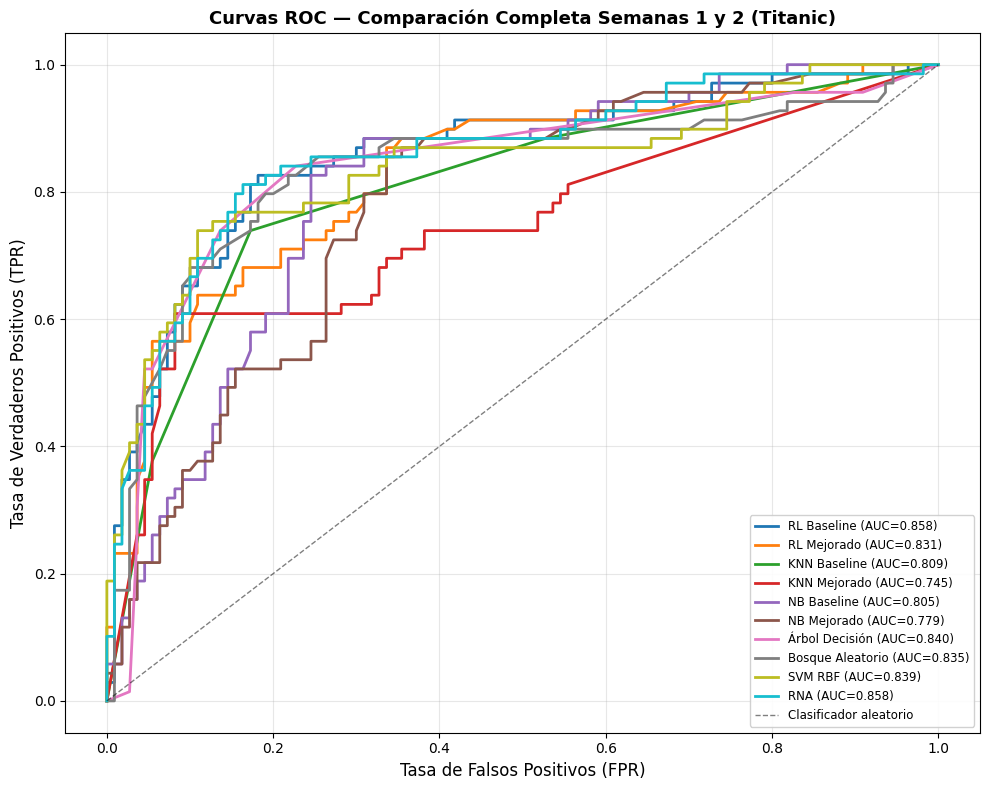

In [134]:
# ── Curvas ROC superpuestas — todos los modelos ───────────────────────────────
modelos_roc_all = [
    ('RL Baseline',       y_prob_rl_base),
    ('RL Mejorado',       y_prob_rl_mejor),
    ('KNN Baseline',      y_prob_knn_base),
    ('KNN Mejorado',      y_prob_knn_mejor),
    ('NB Baseline',       y_prob_nb_base),
    ('NB Mejorado',       y_prob_nb_mejor),
    ('Árbol Decisión',    y_prob_dt),
    ('Bosque Aleatorio',  y_prob_rf),
    ('SVM RBF',           y_prob_svm),
    ('RNA',               y_prob_rna),
]

cmap_roc = plt.cm.get_cmap('tab10', len(modelos_roc_all))

plt.figure(figsize=(10, 8))
for j, (nombre, probs) in enumerate(modelos_roc_all):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, lw=2, color=cmap_roc(j),
             label=f'{nombre} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC — Comparación Completa Semanas 1 y 2 (Titanic)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=8.5, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Interpretación Final: Comparación de Modelos — Semanas 1 y 2 (Titanic)**

La comparación de los diez modelos sobre el Titanic revela un patrón distinto
al del dataset de cáncer: el techo de rendimiento es más bajo (accuracy ~80-83%
vs ~95-98% en cáncer) porque el Titanic tiene factores de supervivencia no
registrados en el dataset (ubicación exacta en el barco, decisiones individuales,
acceso a los botes). Ningún modelo, independientemente de su complejidad, puede
superar la incertidumbre inherente del problema.

**Sobre las familias de algoritmos:**
Los modelos de Semana 1 establecen una línea base sólida. La Regresión Logística
captura la mayor parte de la señal disponible gracias a la casi-linealidad de
las variables clave (Sex, Pclass son casi suficientes). Los modelos de Semana 2
introducen capacidad no lineal adicional, pero la mejora marginal es limitada
porque la señal principal ya es capturada linealmente.

**Sobre la métrica prioritaria:**
A diferencia del diagnóstico médico, en el Titanic el F1-score es la métrica
más balanceada. La curva ROC superpuesta es especialmente informativa aquí:
los modelos cuyas curvas se encuentran más cerca de la esquina superior izquierda
tienen mayor capacidad discriminante global.

**Sobre el valor de los ítems extra:**
La validación cruzada k=10 (Sección 9.5) revela si los resultados son estables
o dependientes de la partición, algo crítico con solo 891 muestras. El análisis
de umbral (Sección 9.6) permite optimizar la RNA más allá del default de 0.5,
lo que puede ser la diferencia entre un F1 competitivo y el mejor del conjunto.